# import needded columns

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,AdaBoostRegressor,VotingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB


from sklearn.cluster import KMeans,DBSCAN

from sklearn.metrics import accuracy_score,mean_absolute_error,confusion_matrix,classification_report,mean_squared_error

from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger,ModelCheckpoint



## **Data Representation**

In [23]:
df=pd.read_csv('D:\\PROJECTS\PROJECT 38\\Student_Performance.csv')
df

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\3417551349.py:1: SyntaxWarning: invalid escape sequence '\P'
  df=pd.read_csv('D:\\PROJECTS\PROJECT 38\\Student_Performance.csv')


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [24]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [4]:
df.tail()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f
24999,11621,18,other,public,no formal,0.7,60.3,yes,30-60 min,no,mixed,36.5,45.1,16.5,31.4,f


In [25]:
df.sample()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
14727,14728,18,male,private,diploma,7.8,81.9,yes,15-30 min,yes,notes,93.2,97.3,83.9,93.0,b


In [26]:
df.index

RangeIndex(start=0, stop=25000, step=1)

In [27]:
df.values

array([[1, 14, 'male', ..., 57.0, 53.1, 'e'],
       [2, 18, 'female', ..., 64.8, 61.3, 'd'],
       [3, 17, 'female', ..., 79.2, 89.6, 'b'],
       ...,
       [4422, 19, 'other', ..., 36.1, 36.7, 'f'],
       [7858, 14, 'male', ..., 7.3, 34.1, 'f'],
       [11621, 18, 'other', ..., 16.5, 31.4, 'f']],
      shape=(25000, 16), dtype=object)

In [28]:
df.value_counts()

student_id  age  gender  school_type  parent_education  study_hours  attendance_percentage  internet_access  travel_time  extra_activities  study_method   math_score  science_score  english_score  overall_score  final_grade
4781        19   male    public       diploma           5.8          55.3                   yes              >60 min      yes               textbook       65.6        79.8           82.0           68.4           d              7
3720        15   male    private      no formal         3.1          72.5                   yes              15-30 min    yes               coaching       52.0        52.1           51.4           58.2           d              6
13396       14   male    public       diploma           4.3          85.8                   no               <15 min      no                notes          65.1        54.0           41.6           59.4           d              6
14821       18   other   public       high school       3.3          63.7                

In [29]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [30]:
df.shape

(25000, 16)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

## **Data Wrangling**

**Missing Values**

In [32]:
df.isna().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

**DUPLICATED Values**

In [33]:
df.duplicated().sum()

np.int64(10000)

In [34]:
df[df.duplicated()]


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
15000,7271,15,male,private,no formal,1.8,51.6,yes,>60 min,yes,mixed,31.2,25.6,22.9,25.2,f
15001,861,19,other,public,post graduate,0.8,98.3,no,15-30 min,no,coaching,54.3,45.4,51.5,53.9,e
15002,5391,15,female,private,phd,1.9,62.4,yes,30-60 min,yes,textbook,36.0,32.7,28.6,40.0,f
15003,13419,16,other,private,graduate,0.7,51.4,yes,15-30 min,yes,coaching,59.4,23.5,24.6,30.3,f
15004,5192,19,female,public,post graduate,4.9,67.6,yes,<15 min,no,coaching,78.5,83.9,63.5,69.0,d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [35]:
df[df.duplicated(keep=False)]

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
5,6,19,male,public,no formal,3.8,69.6,yes,>60 min,yes,coaching,51.5,78.3,63.9,63.5,d
6,7,14,female,private,post graduate,1.8,81.6,yes,30-60 min,no,textbook,41.9,29.4,39.2,39.1,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [36]:
# حذف الصفوف المكررة تمامًا والاحتفاظ بنسخة واحدة فقط
df = df.drop_duplicates(keep='first')


In [37]:
df

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,17,male,private,graduate,1.8,53.2,yes,15-30 min,no,group study,37.1,37.1,26.8,38.4,f
14996,14997,17,other,private,diploma,6.7,63.5,no,<15 min,yes,mixed,84.4,67.2,96.2,78.8,c
14997,14998,17,male,private,phd,5.2,58.2,yes,30-60 min,no,group study,69.0,57.2,74.1,64.3,d
14998,14999,16,other,private,graduate,1.0,68.7,yes,30-60 min,yes,textbook,24.2,41.4,30.5,33.6,f


## **Exploratory Data Analysis**

#### **Univariate Analysis**

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   school_type            15000 non-null  object 
 4   parent_education       15000 non-null  object 
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  object 
 8   travel_time            15000 non-null  object 
 9   extra_activities       15000 non-null  object 
 10  study_method           15000 non-null  object 
 11  math_score             15000 non-null  float64
 12  science_score          15000 non-null  float64
 13  english_score          15000 non-null  float64
 14  overall_score          15000 non-null  float64
 15  final_g

In [39]:
df['final_grade'].value_counts()

final_grade
d    3770
c    3697
e    3378
f    1796
b    1638
a     721
Name: count, dtype: int64

In [40]:
df['overall_score'].describe()

count    15000.000000
mean        64.015500
std         18.977811
min         14.500000
25%         49.000000
50%         64.300000
75%         79.100000
max        100.000000
Name: overall_score, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\19325852.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax=sns.histplot(df['overall_score'], bins=15, edgecolor='black', alpha=0.8,palette='tab10',shrink=0.5)


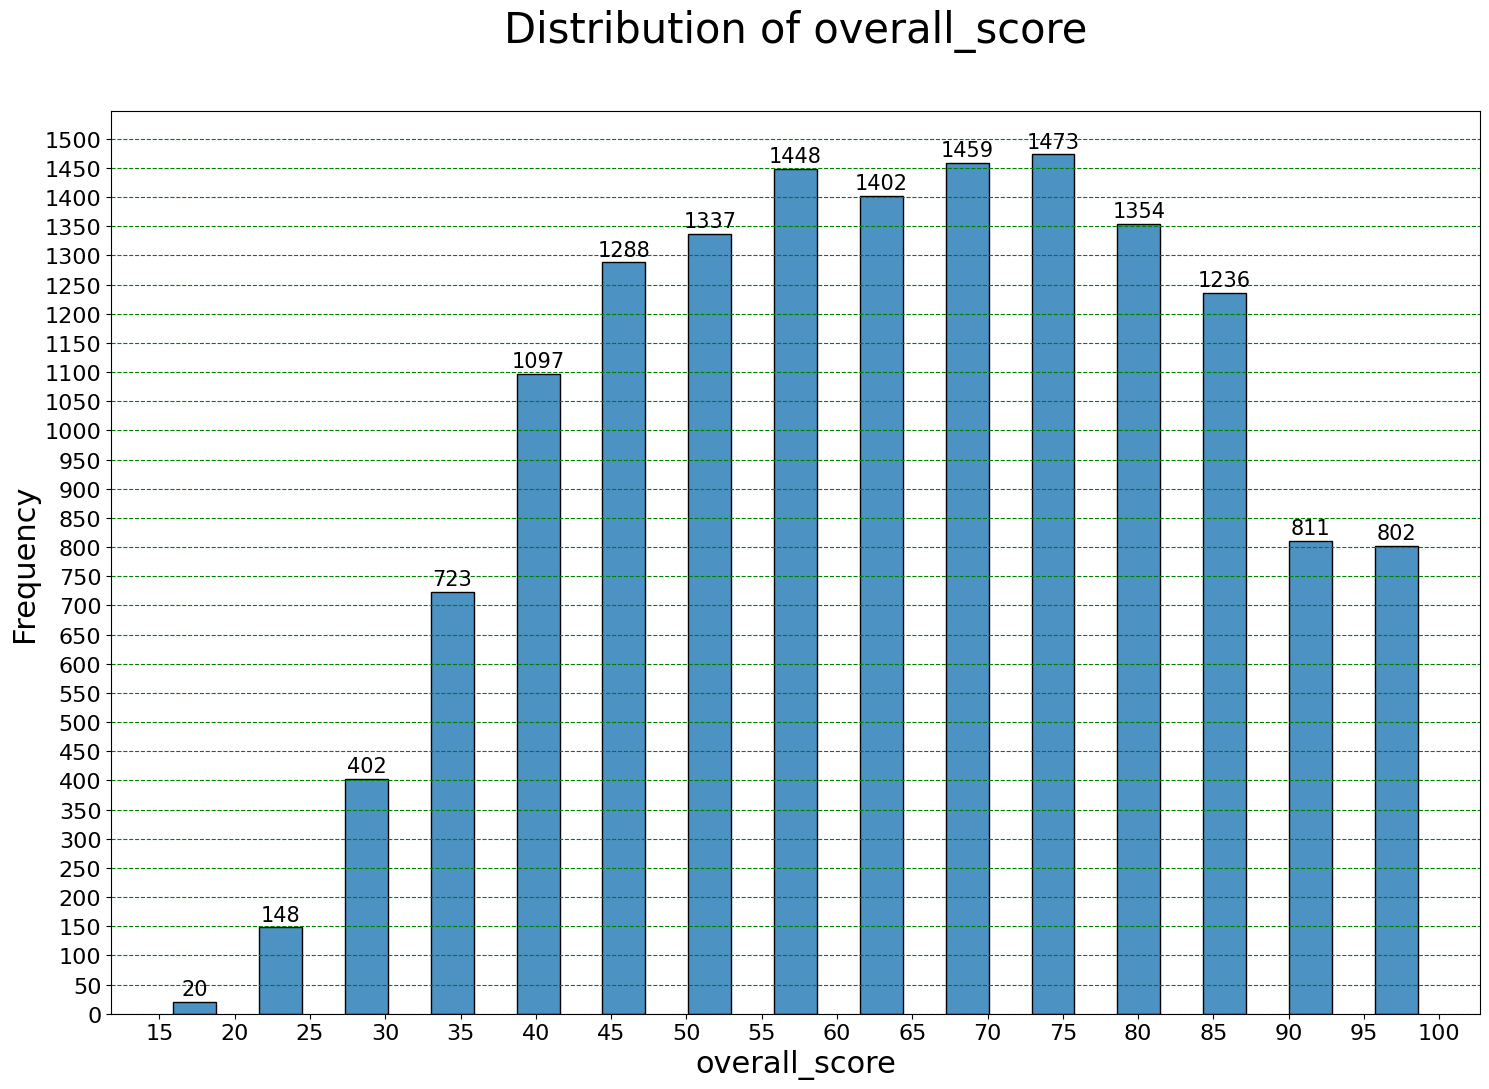

In [47]:
plt.figure(figsize=(15,11), facecolor="white")

ax=sns.histplot(df['overall_score'], bins=15, edgecolor='black', alpha=0.8,palette='tab10',shrink=0.5)

plt.title("Distribution of overall_score", fontsize=30, pad=50)
plt.xlabel("overall_score", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(15,105,5),fontsize=16)
plt.yticks(range(0,1550,50),fontsize=16)

plt.grid(axis='y',linestyle='--',color='green', alpha=1)

plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=15, padding=2)
plt.show()

In [48]:
df['english_score'].describe()

count    15000.000000
mean        63.709227
std         20.860201
min          0.000000
25%         48.300000
50%         64.200000
75%         80.000000
max        100.000000
Name: english_score, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\1386194236.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\1386194236.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


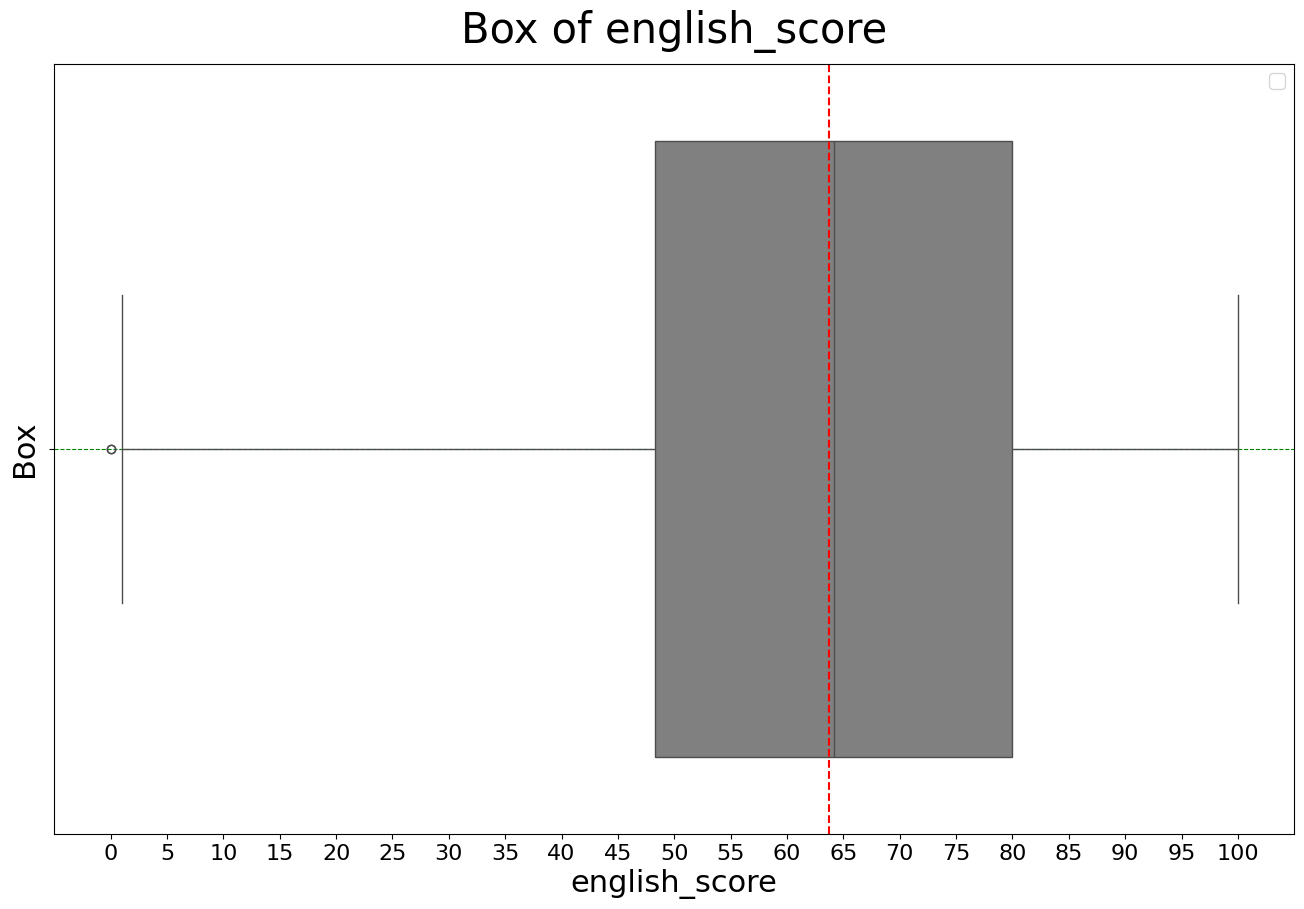

In [49]:
plt.figure(figsize=(16,10))
sns.boxplot(data=df['english_score'],orient='h',color='gray')

plt.title('Box of english_score',fontsize=30,pad=15)
plt.xlabel('english_score',fontsize=22)
plt.ylabel('Box',fontsize=22)
plt.xticks(range(0,105,5),fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.legend(fontsize=14)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
plt.axvline(df['english_score'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='mean')
plt.show()



In [50]:
df['science_score'].describe()

count    15000.000000
mean        63.751227
std         21.027675
min          0.000000
25%         48.100000
50%         64.000000
75%         80.100000
max        100.000000
Name: science_score, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\2627124471.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\2627124471.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


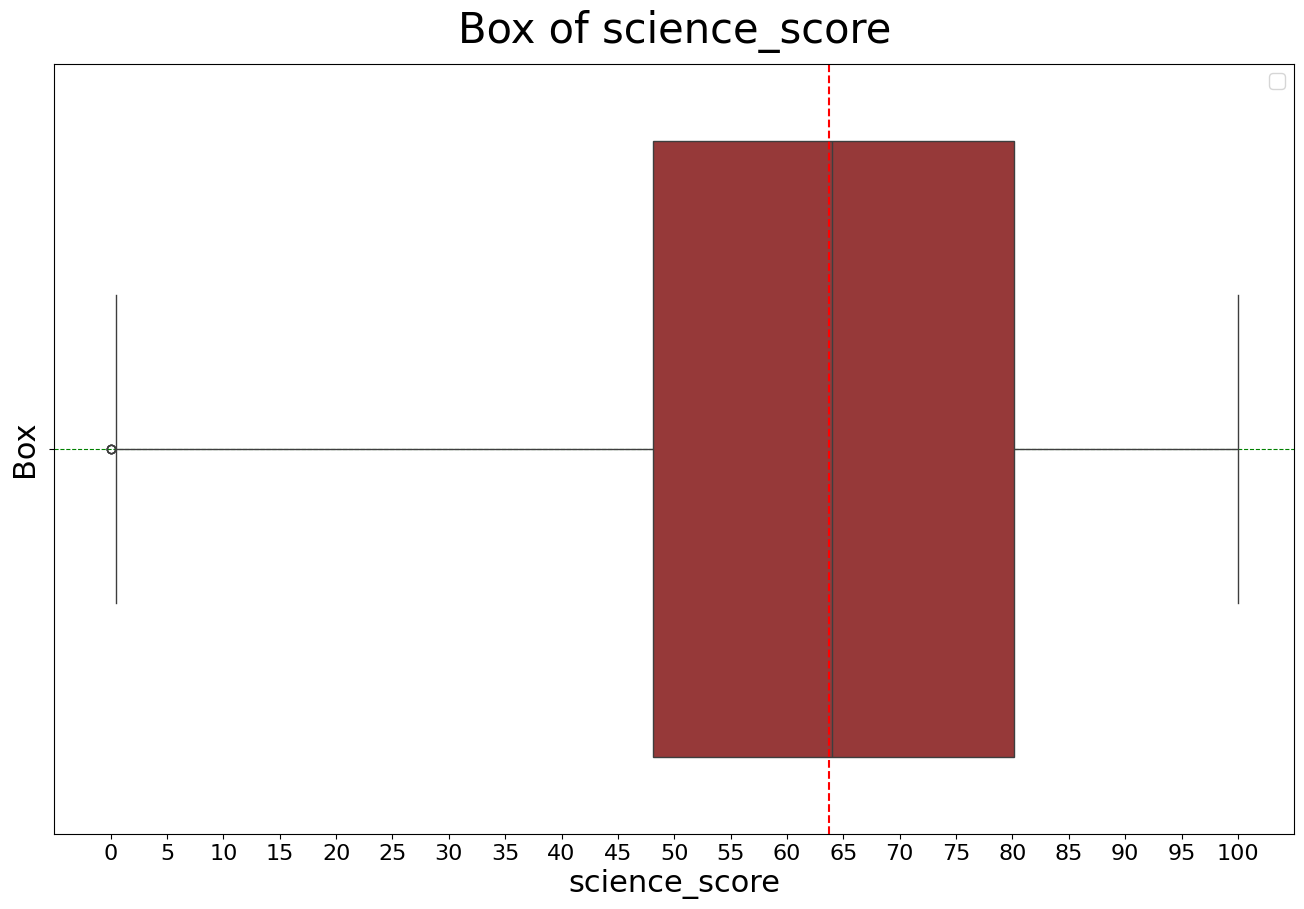

In [51]:
plt.figure(figsize=(16,10))
sns.boxplot(data=df['science_score'],orient='h',color='brown')

plt.title('Box of science_score',fontsize=30,pad=15)
plt.xlabel('science_score',fontsize=22)
plt.ylabel('Box',fontsize=22)
plt.xticks(range(0,105,5),fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.legend(fontsize=14)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
plt.axvline(df['science_score'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='mean')
plt.show()



In [52]:
df['math_score'].describe()

count    15000.000000
mean        63.774553
std         20.919958
min          0.000000
25%         48.200000
50%         64.100000
75%         80.100000
max        100.000000
Name: math_score, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\672550882.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\672550882.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


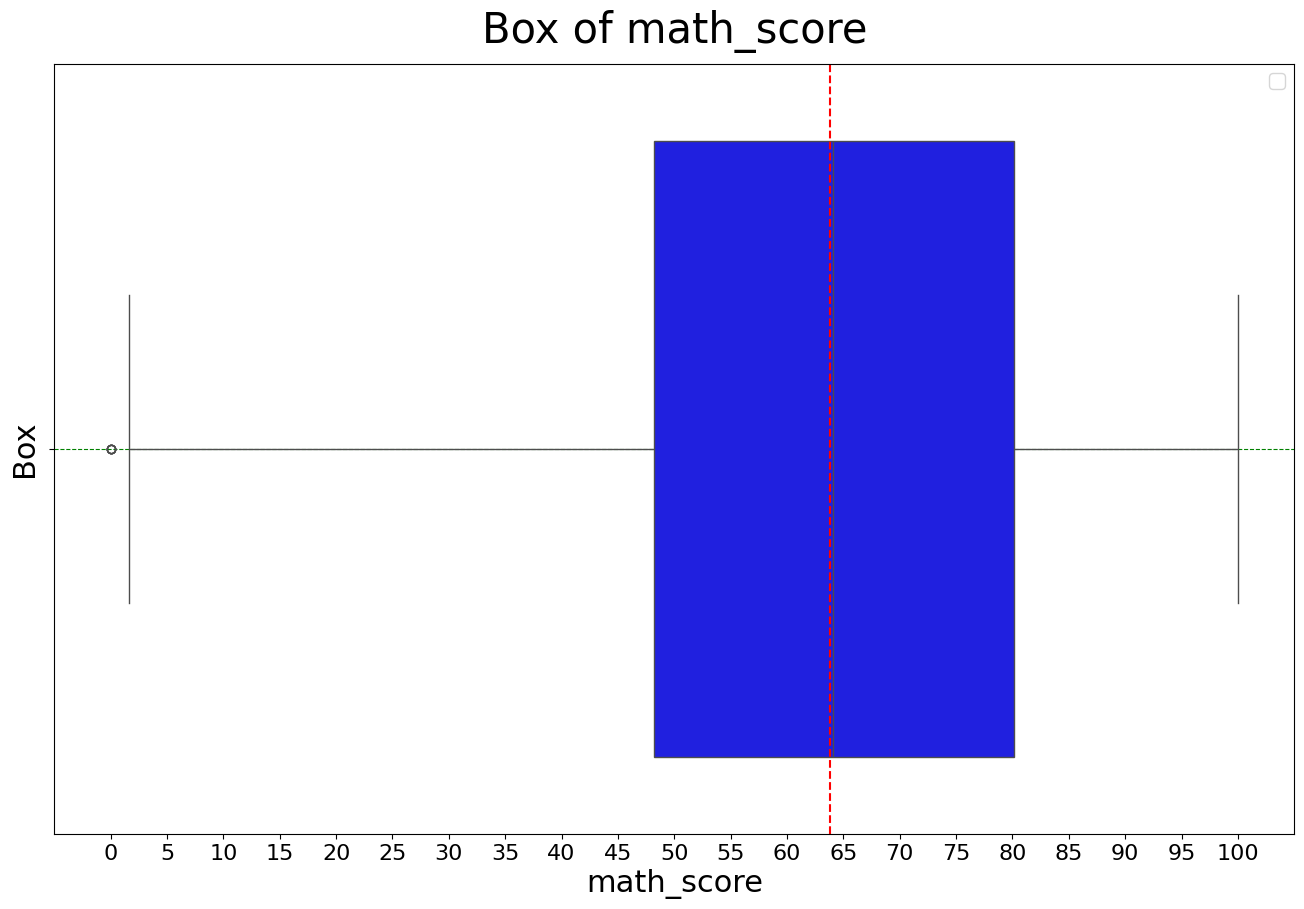

In [53]:
plt.figure(figsize=(16,10))
sns.boxplot(data=df['math_score'],orient='h',color='blue')

plt.title('Box of math_score',fontsize=30,pad=15)
plt.xlabel('math_score',fontsize=22)
plt.ylabel('Box',fontsize=22)
plt.xticks(range(0,105,5),fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.legend(fontsize=14)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
plt.axvline(df['math_score'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='mean')
plt.show()



In [54]:
df['study_method'].value_counts()

study_method
mixed            2602
textbook         2546
notes            2515
online videos    2468
group study      2447
coaching         2422
Name: count, dtype: int64

In [55]:
df['extra_activities'].value_counts()

extra_activities
no     7506
yes    7494
Name: count, dtype: int64

In [56]:
df['travel_time'].value_counts()

travel_time
15-30 min    3823
30-60 min    3813
>60 min      3716
<15 min      3648
Name: count, dtype: int64

In [57]:
df['internet_access'].value_counts()

internet_access
yes    12754
no      2246
Name: count, dtype: int64

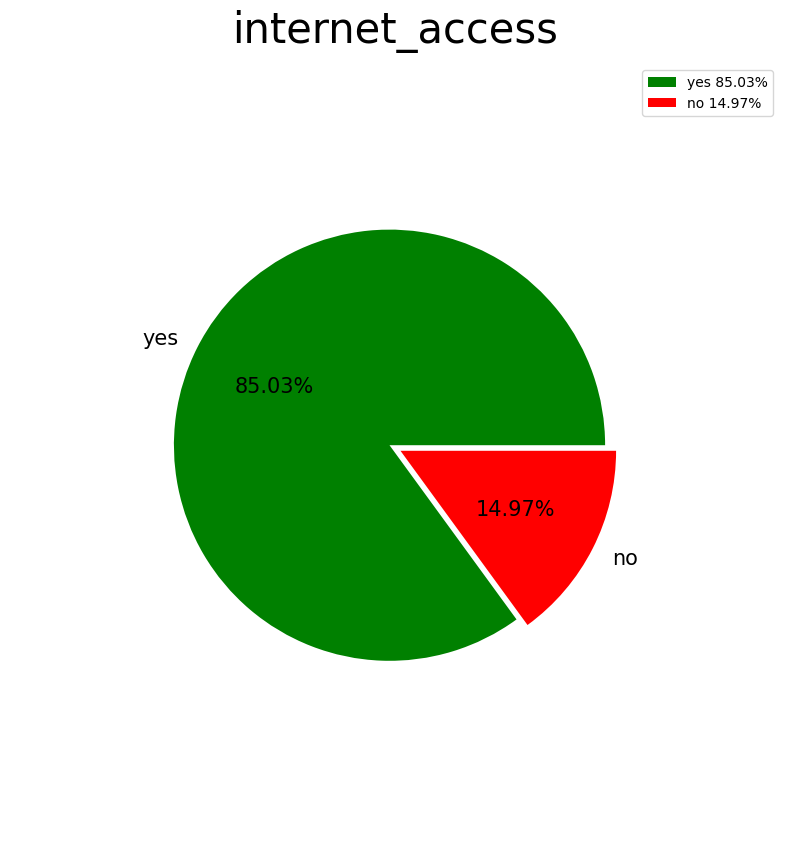

In [58]:
plt.figure(figsize=(16,10))
plt.pie(df['internet_access'].value_counts().values,labels=df['internet_access'].value_counts().index,colors=['green','red'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('internet_access',fontsize=30,pad=15)
plt.legend(['yes 85.03%', 'no 14.97%'])

plt.xticks()
plt.yticks()
plt.show()

In [59]:
df['attendance_percentage'].describe()

count    15000.000000
mean        74.991760
std         14.401139
min         50.000000
25%         62.600000
50%         75.000000
75%         87.400000
max        100.000000
Name: attendance_percentage, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\197240074.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\197240074.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


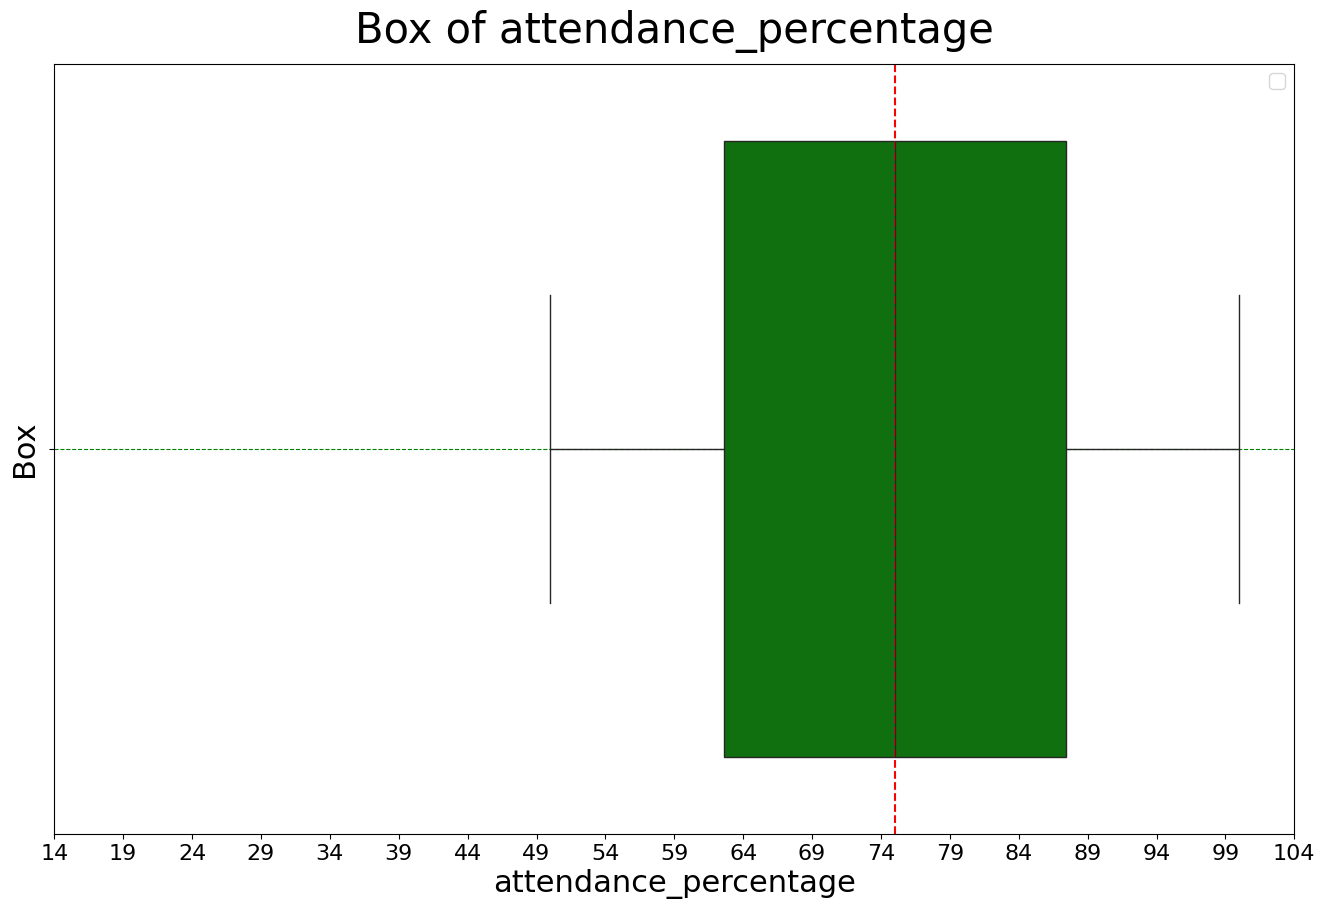

In [60]:
plt.figure(figsize=(16,10))
sns.boxplot(data=df['attendance_percentage'],orient='h',color='green')

plt.title('Box of attendance_percentage',fontsize=30,pad=15)
plt.xlabel('attendance_percentage',fontsize=22)
plt.ylabel('Box',fontsize=22)
plt.xticks(range(14,105,5),fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.legend(fontsize=14)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
plt.axvline(df['attendance_percentage'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='mean')
plt.show()



In [61]:
df['study_hours'].describe()

count    15000.00000
mean         4.25936
std          2.17244
min          0.50000
25%          2.40000
50%          4.30000
75%          6.10000
max          8.00000
Name: study_hours, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\351628299.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax=sns.histplot(df['study_hours'], bins=15, edgecolor='black', alpha=0.8,palette='Set1',shrink=0.5)


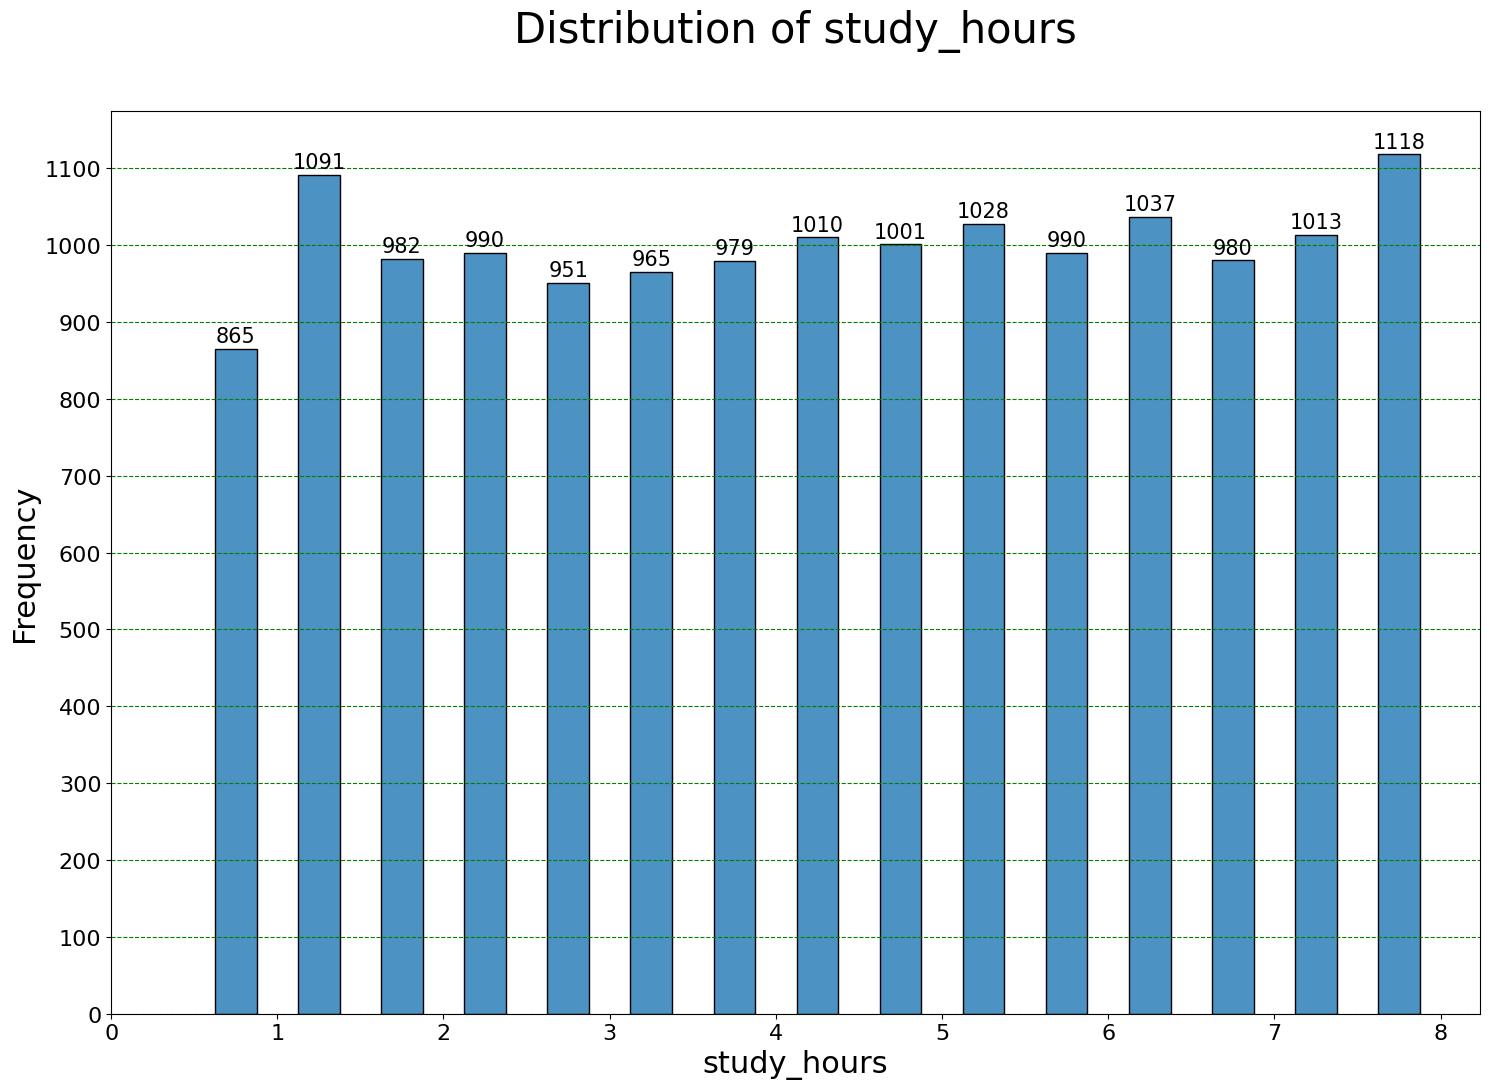

In [64]:
plt.figure(figsize=(15,11), facecolor="white")

ax=sns.histplot(df['study_hours'], bins=15, edgecolor='black', alpha=0.8,palette='Set1',shrink=0.5)

plt.title("Distribution of study_hours", fontsize=30, pad=50)
plt.xlabel("study_hours", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(0,9,1),fontsize=16)
plt.yticks(range(0,1200,100),fontsize=16)

plt.grid(axis='y',linestyle='--',color='green', alpha=1)

plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=15, padding=2)
plt.show()

In [65]:
df['parent_education'].value_counts()

parent_education
diploma          2581
post graduate    2535
high school      2532
graduate         2481
no formal        2445
phd              2426
Name: count, dtype: int64

In [66]:
df['school_type'].value_counts()

school_type
private    7587
public     7413
Name: count, dtype: int64

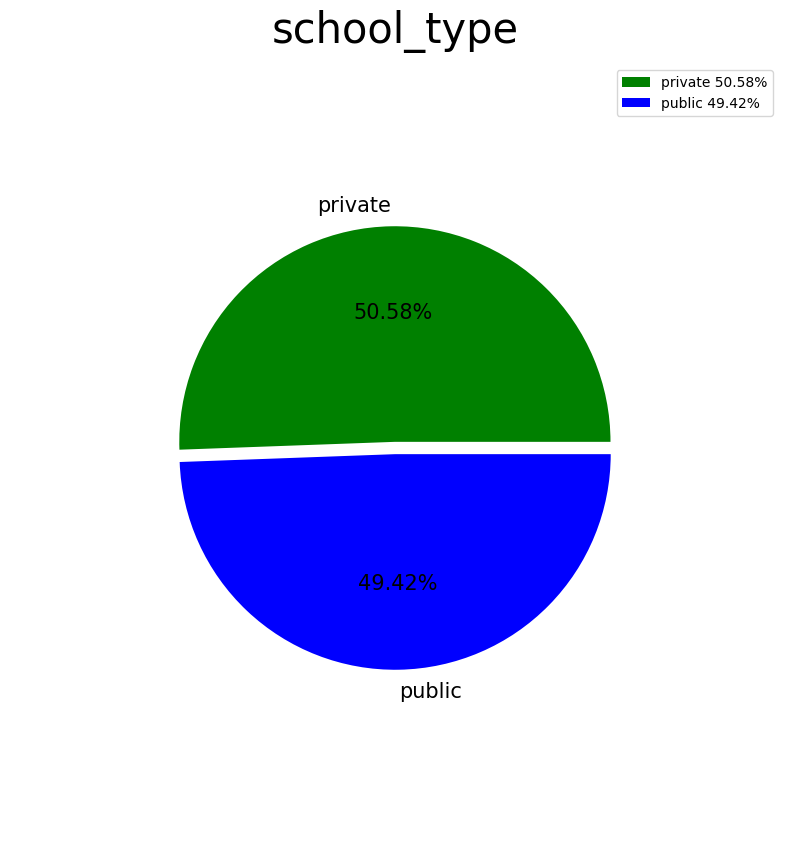

In [67]:
plt.figure(figsize=(16,10))
plt.pie(df['school_type'].value_counts().values,labels=df['school_type'].value_counts().index,colors=['green','blue'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('school_type',fontsize=30,pad=15)
plt.legend(['private 50.58%', 'public 49.42%'])

plt.xticks()
plt.yticks()
plt.show()

In [68]:
df['gender'].value_counts()

gender
other     5042
male      4979
female    4979
Name: count, dtype: int64

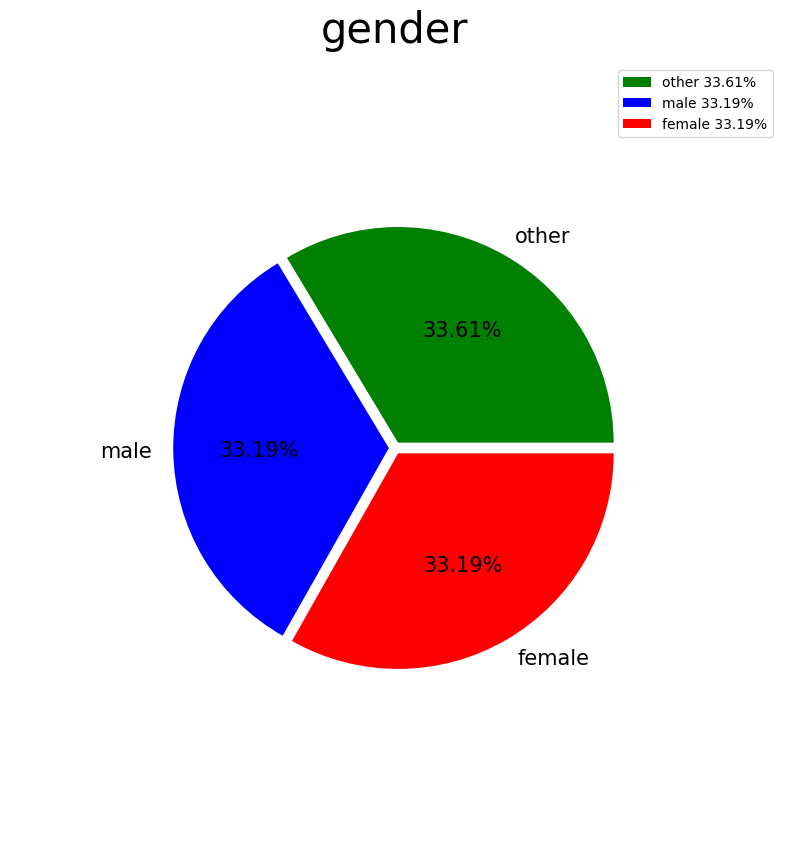

In [69]:
plt.figure(figsize=(16,10))
plt.pie(df['gender'].value_counts().values,labels=df['gender'].value_counts().index,colors=['green','blue','red'],explode=[0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('gender',fontsize=30,pad=15)
plt.legend(['other 33.61%', 'male 33.19%','female 33.19%'])

plt.xticks()
plt.yticks()
plt.show()

In [70]:
df['age'].describe()

count    15000.000000
mean        16.476400
std          1.704475
min         14.000000
25%         15.000000
50%         16.000000
75%         18.000000
max         19.000000
Name: age, dtype: float64

In [73]:
df['student_id'].describe()

count    15000.000000
mean      7500.500000
std       4330.271354
min          1.000000
25%       3750.750000
50%       7500.500000
75%      11250.250000
max      15000.000000
Name: student_id, dtype: float64

#### **Bivariate Analysis**

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   school_type            15000 non-null  object 
 4   parent_education       15000 non-null  object 
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  object 
 8   travel_time            15000 non-null  object 
 9   extra_activities       15000 non-null  object 
 10  study_method           15000 non-null  object 
 11  math_score             15000 non-null  float64
 12  science_score          15000 non-null  float64
 13  english_score          15000 non-null  float64
 14  overall_score          15000 non-null  float64
 15  final_g

# extra_activities + final_grade

In [276]:
pd.crosstab(df['extra_activities'],df['final_grade'])

final_grade,a,b,c,d,e,f
extra_activities,,,,,,
no,354,791,1894,1890,1677,900
yes,367,847,1803,1880,1701,896


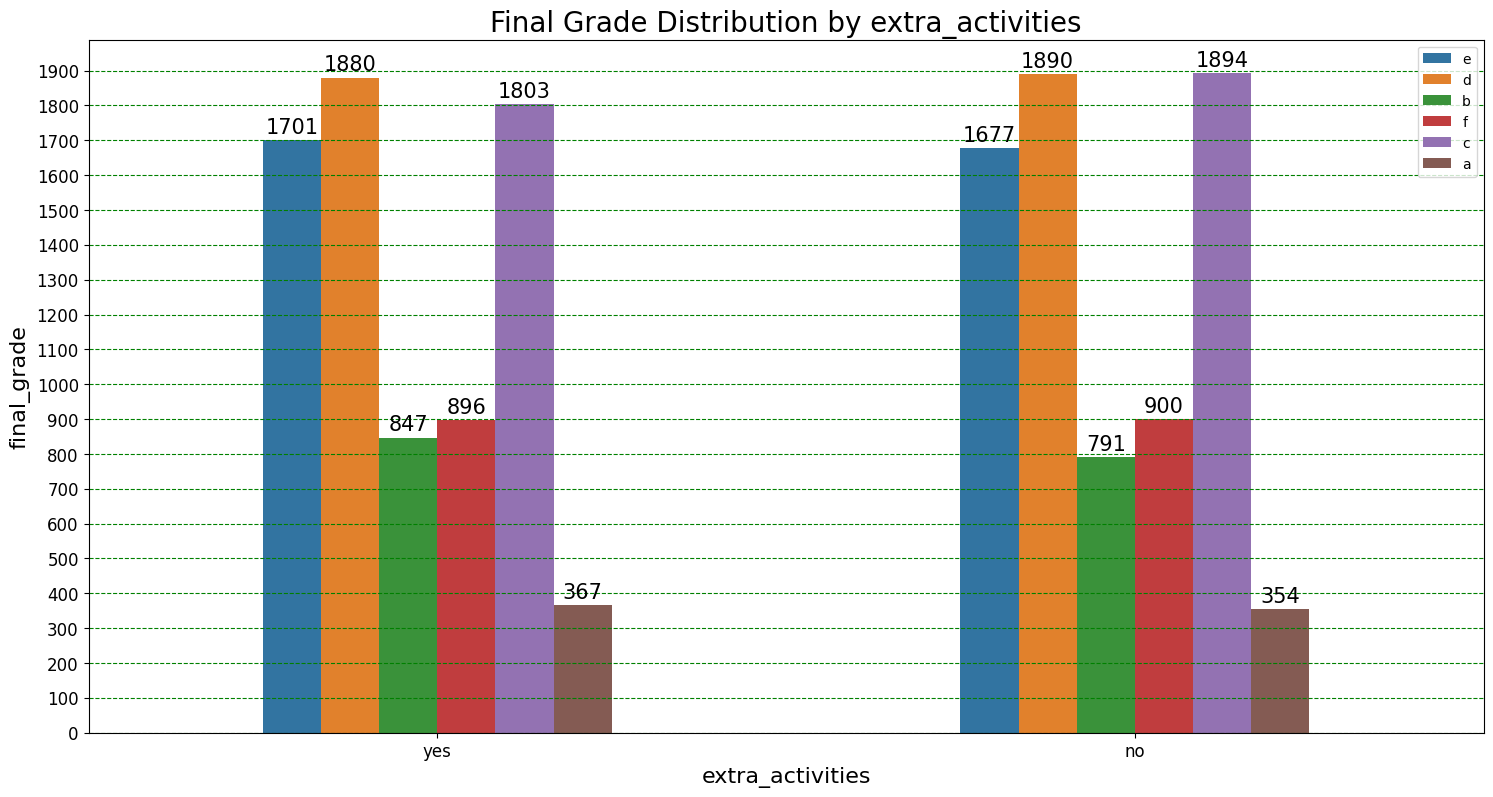

In [86]:
plt.figure(figsize=(18,9)) 
ax=sns.countplot(x='extra_activities', hue='final_grade', data=df,width=0.5)
plt.title('Final Grade Distribution by extra_activities', fontsize=20) 
plt.xlabel('extra_activities', fontsize=16) 
plt.ylabel('final_grade', fontsize=16) 
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
plt.xticks(fontsize=12)
plt.yticks(range(0,2000,100),fontsize=12)

plt.legend() 
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=15, padding=2)
plt.show()

# school_type + final_grade

In [87]:
pd.crosstab(df['school_type'],df['final_grade'])

final_grade,a,b,c,d,e,f
school_type,,,,,,
private,364,818,1852,1950,1712,891
public,357,820,1845,1820,1666,905


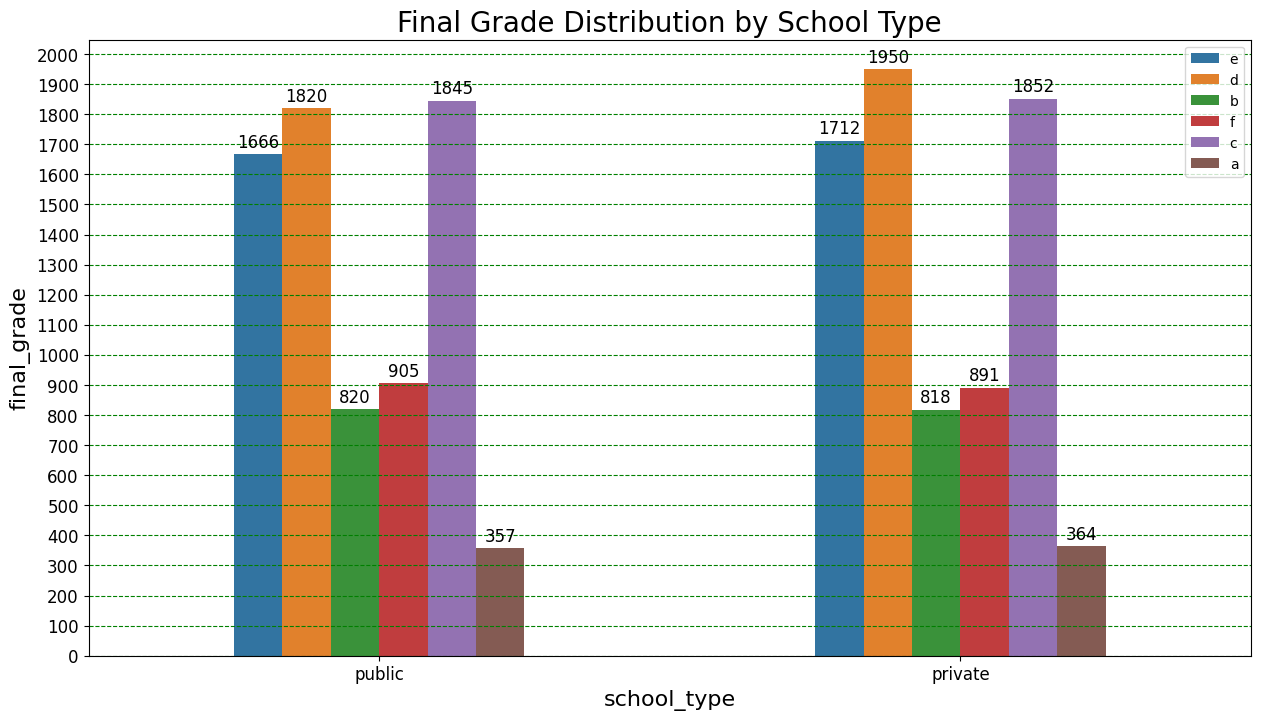

In [94]:
plt.figure(figsize=(15,8)) 
ax=sns.countplot(x='school_type', hue='final_grade', data=df,width=0.5)
plt.title('Final Grade Distribution by School Type', fontsize=20) 
plt.xlabel('school_type', fontsize=16) 
plt.ylabel('final_grade', fontsize=16) 
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)
plt.yticks(range(0,2100,100),fontsize=12)
plt.xticks(fontsize=12)

plt.legend() 
plt.show()

# study_hours + study_method

In [95]:
df.groupby(['study_hours'])['study_method'].value_counts()

study_hours  study_method 
0.5          mixed            20
             coaching         18
             group study      18
             notes            15
             textbook         15
                              ..
8.0          mixed            20
             coaching         17
             textbook         17
             online videos    16
             notes             6
Name: count, Length: 456, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\1467259790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='study_method',y='study_hours',data=df,palette='Set2',orient='v')


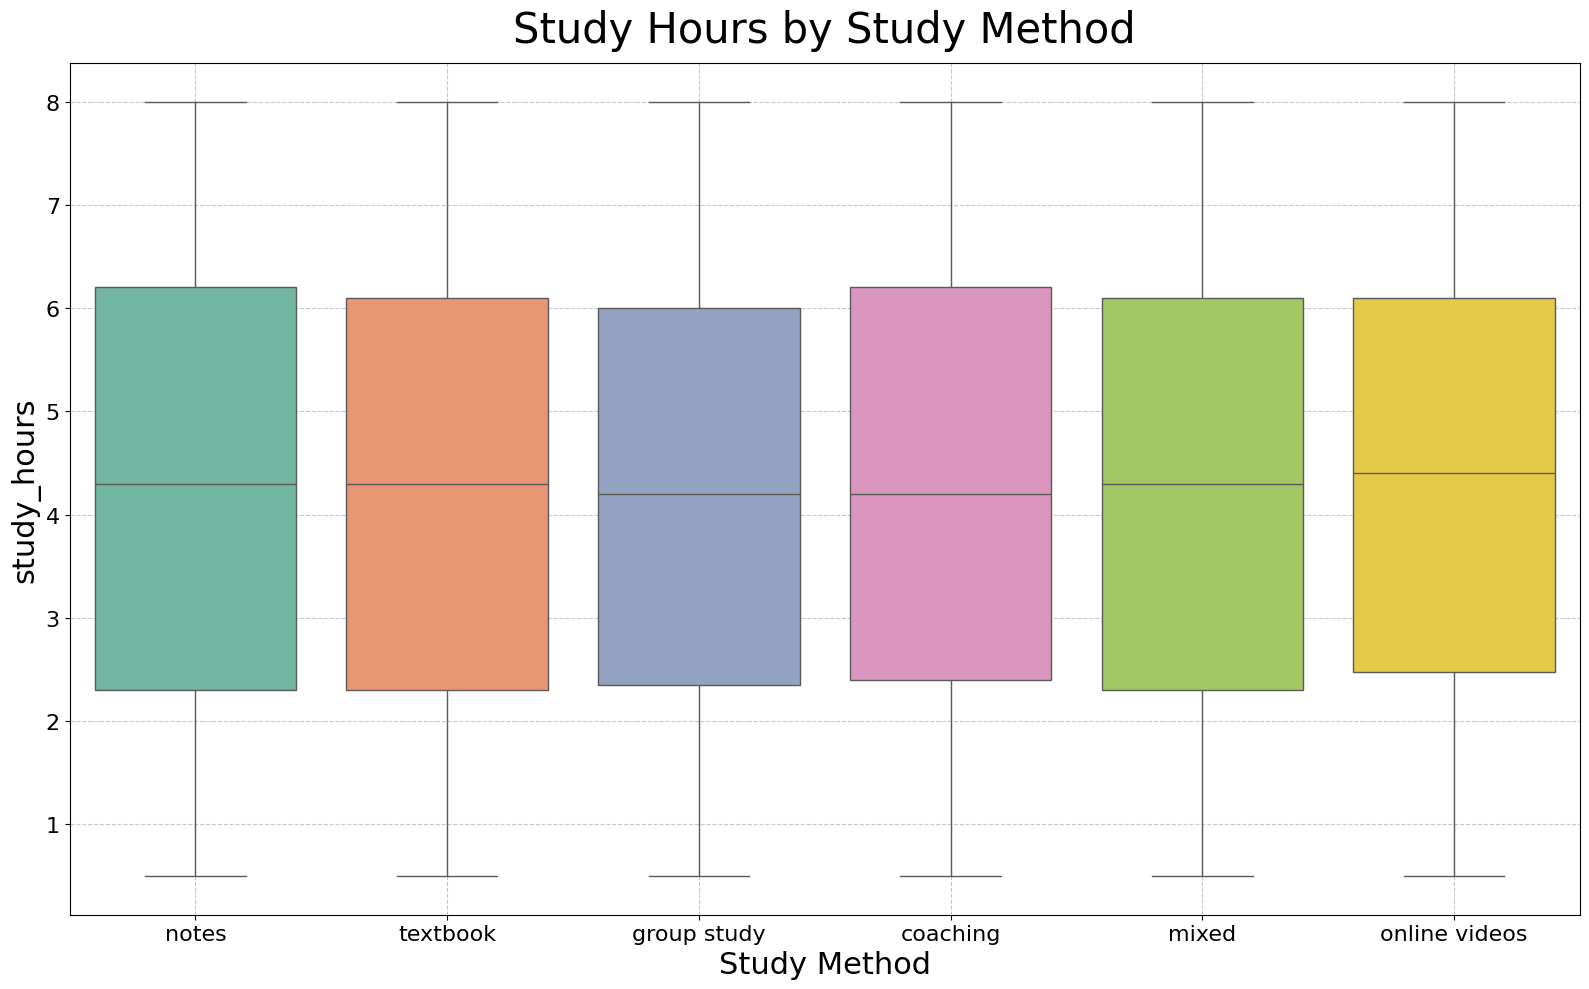

In [96]:
plt.figure(figsize=(16,10))

sns.boxplot(x='study_method',y='study_hours',data=df,palette='Set2',orient='v')

plt.title('Study Hours by Study Method', fontsize=30, pad=15)
plt.xlabel('Study Method', fontsize=22)
plt.ylabel('study_hours', fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# multivariate analysis

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   school_type            15000 non-null  object 
 4   parent_education       15000 non-null  object 
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  object 
 8   travel_time            15000 non-null  object 
 9   extra_activities       15000 non-null  object 
 10  study_method           15000 non-null  object 
 11  math_score             15000 non-null  float64
 12  science_score          15000 non-null  float64
 13  english_score          15000 non-null  float64
 14  overall_score          15000 non-null  float64
 15  final_g

In [103]:
corr=df[['age','study_hours','attendance_percentage','math_score','science_score','english_score','overall_score']].corr()

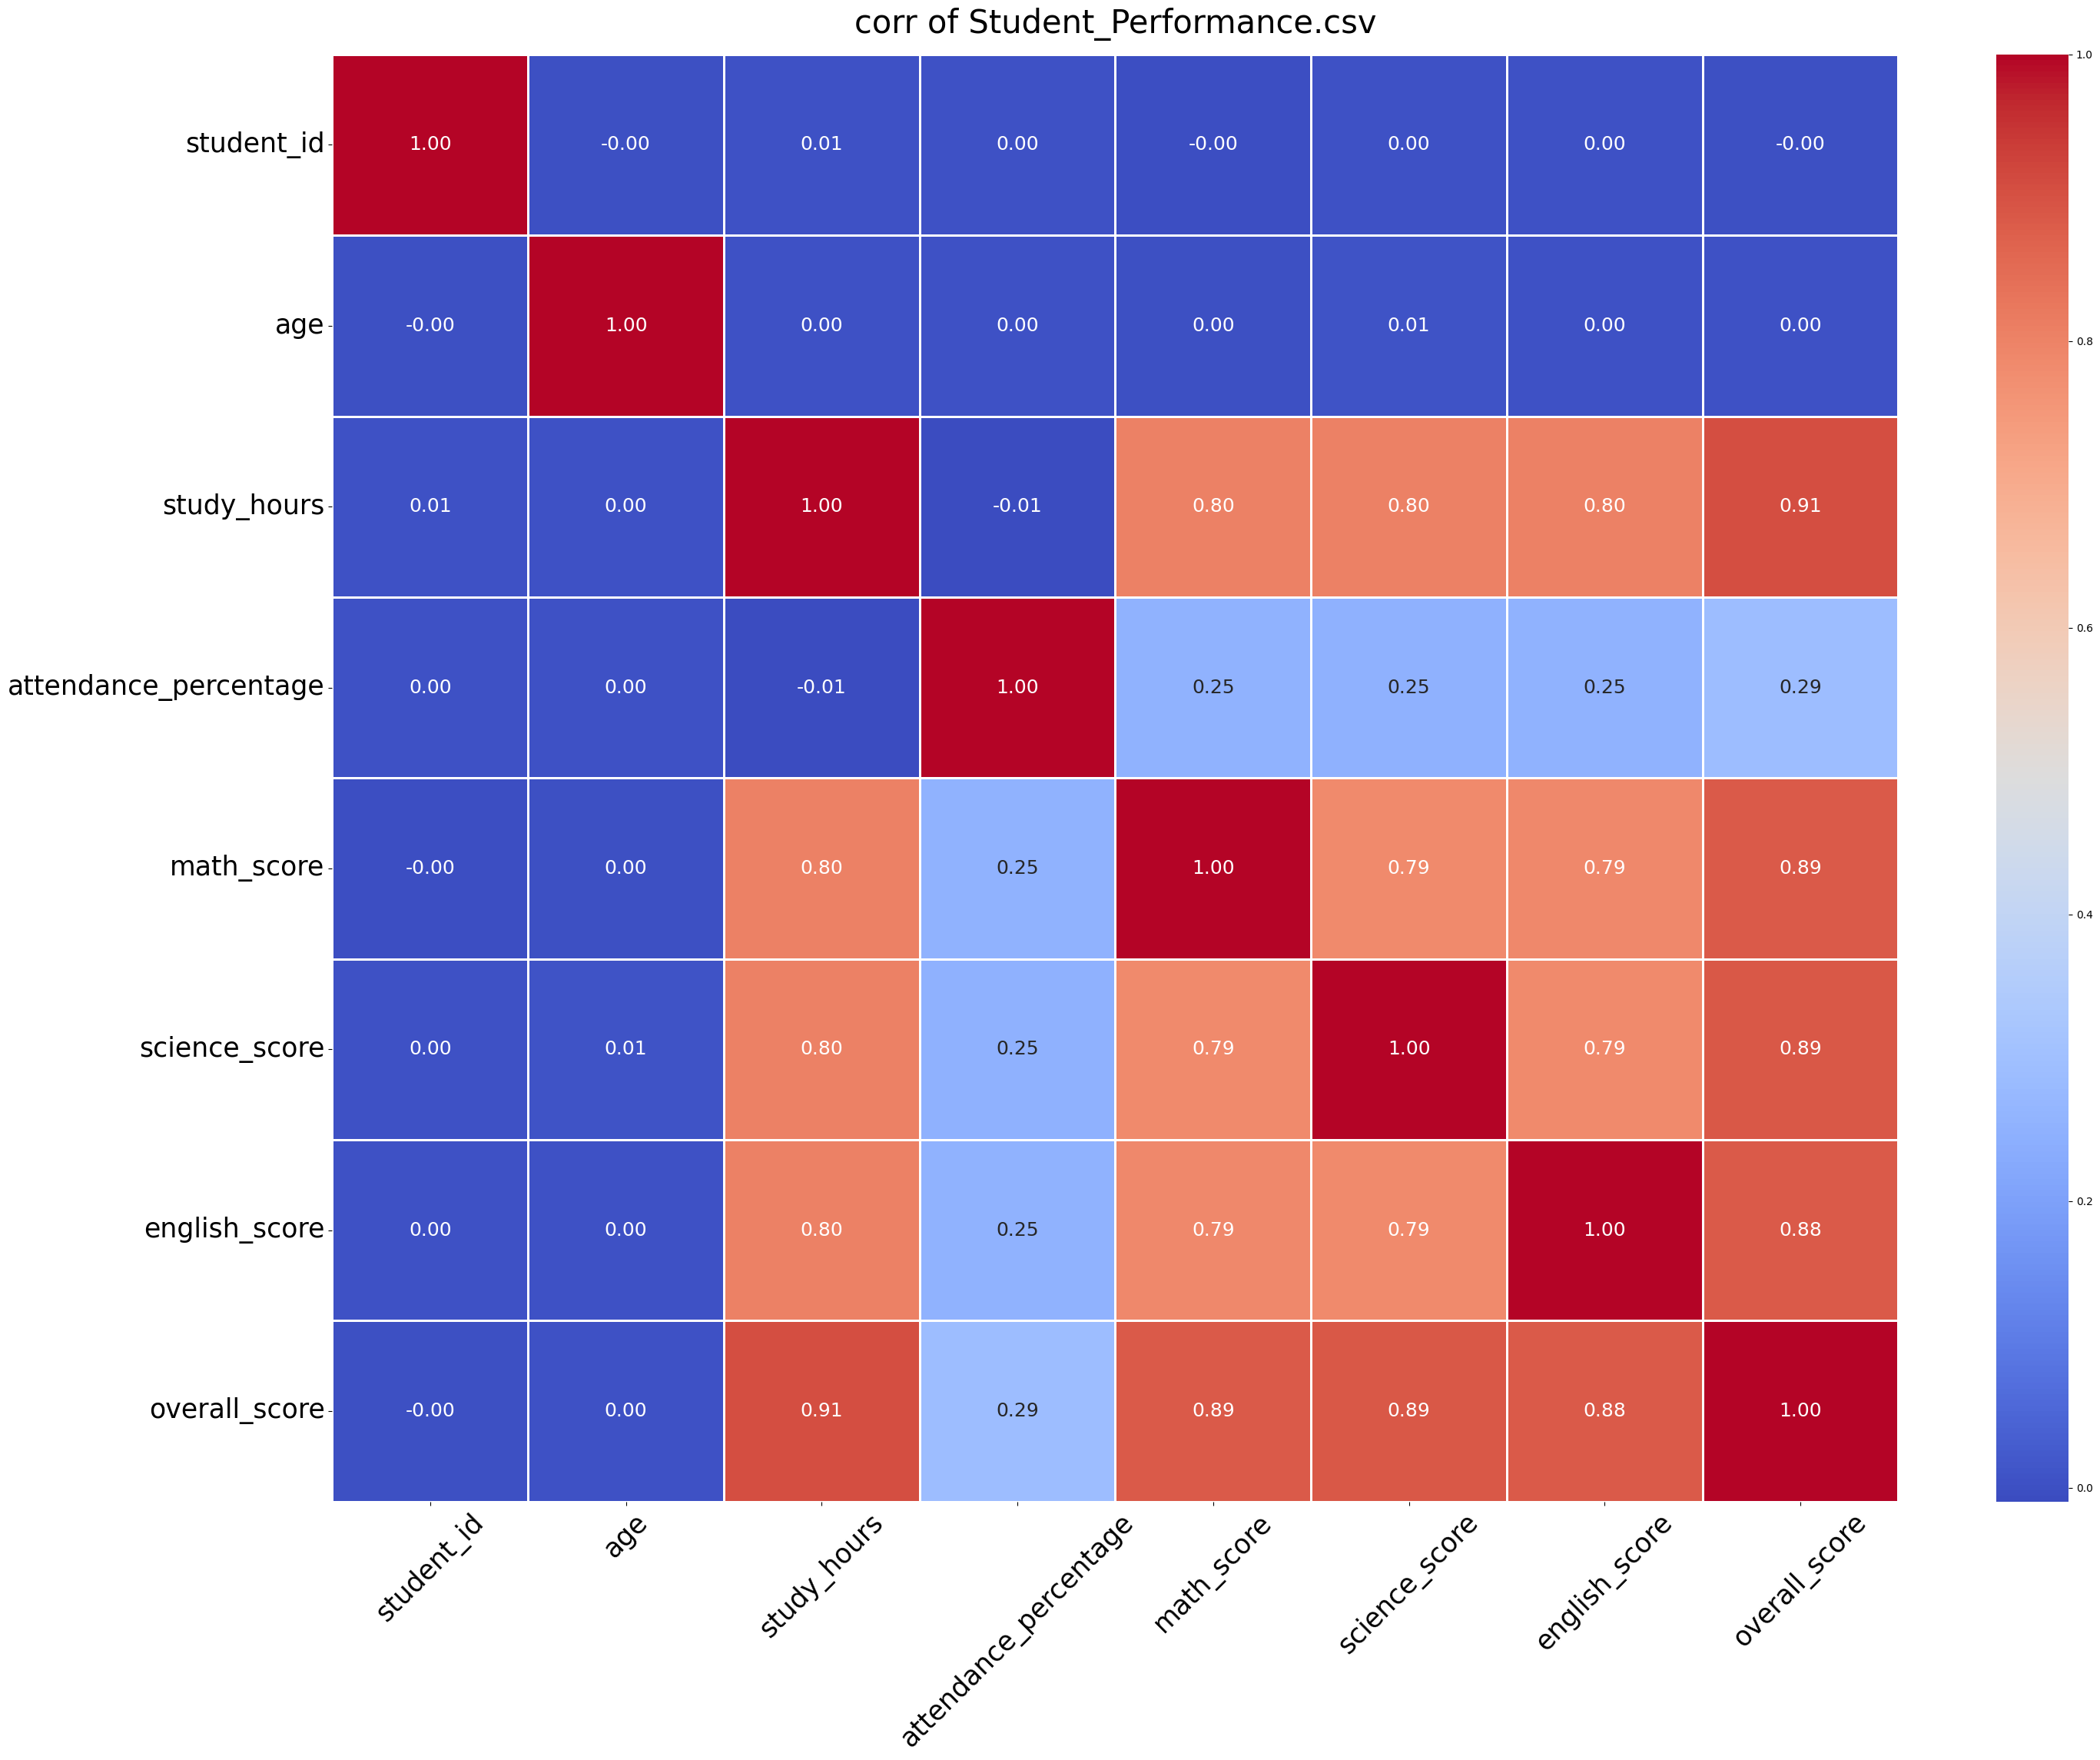

In [104]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(30,23))
sns.heatmap(corr,cmap='coolwarm',annot=True,edgecolor='yellow',linewidths=0.8,fmt='.2f',annot_kws={"size": 18})
plt.title('corr of Student_Performance.csv',fontsize=30,pad=20)
plt.xticks(rotation=45,fontsize=25)
plt.yticks(rotation=0,fontsize=25)

plt.tight_layout()
plt.show()



# study_hours + study_method + final_grade

In [105]:
df.groupby(['study_hours','study_method'])['final_grade'].value_counts()

study_hours  study_method   final_grade
0.5          coaching       e               9
                            f               9
             group study    f              12
                            e               6
             mixed          f              14
                                           ..
8.0          online videos  b               6
                            c               1
             textbook       a               8
                            b               6
                            c               3
Name: count, Length: 1395, dtype: int64

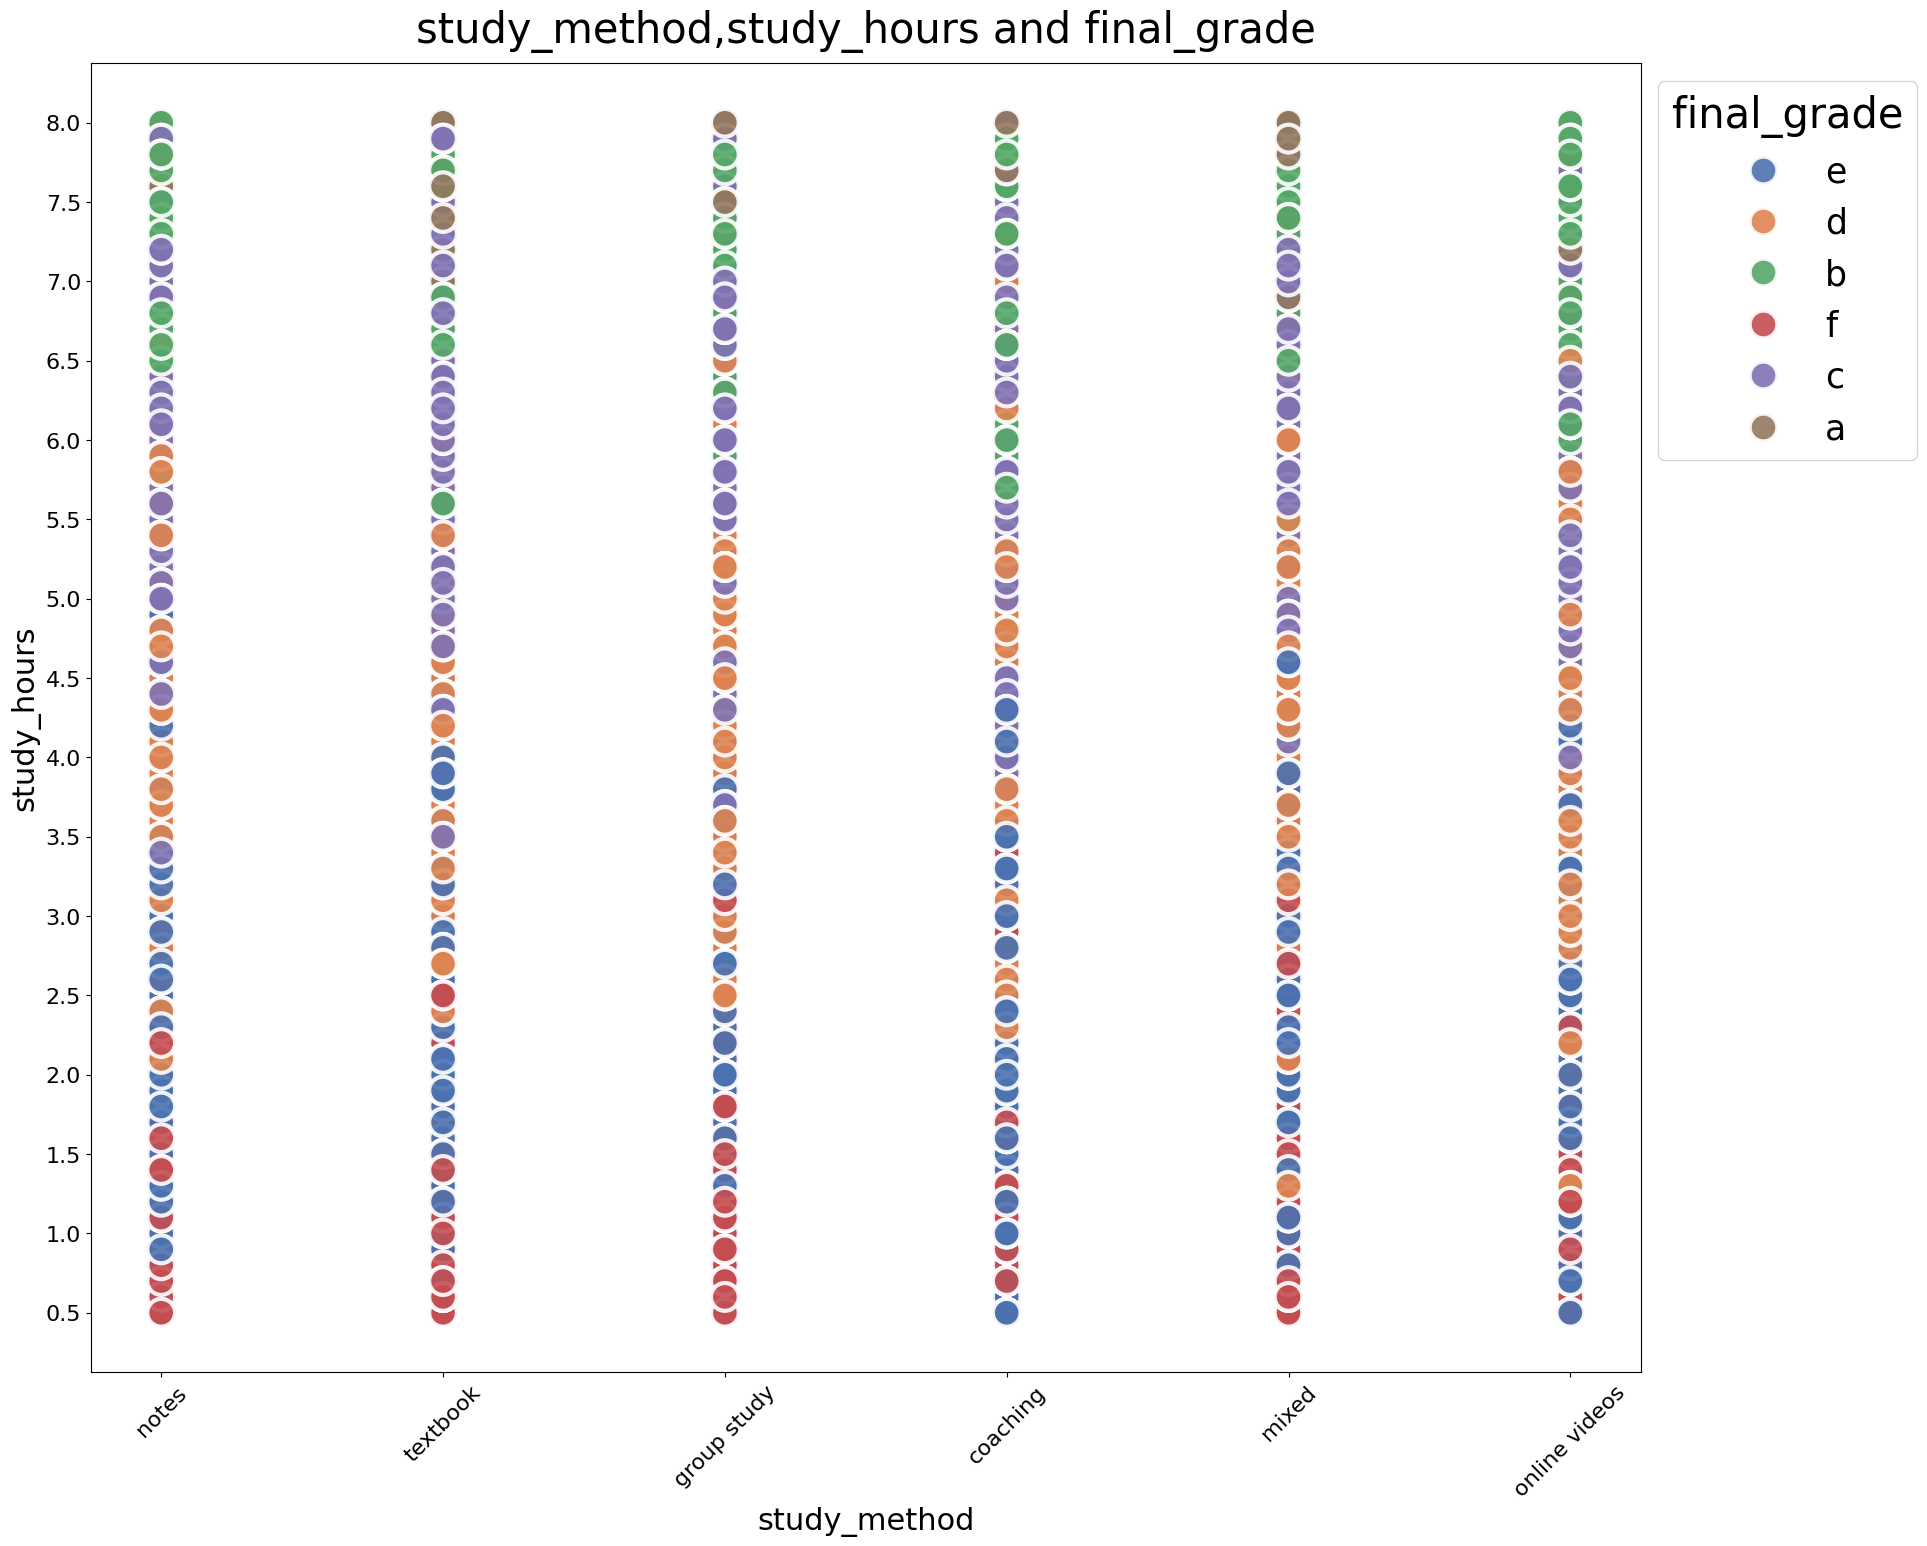

In [106]:
plt.figure(figsize=(20,17))
sns.scatterplot(x='study_method',y='study_hours',hue='final_grade',palette='deep',data=df,linewidth=3,alpha=0.9,s=400)
plt.title('study_method,study_hours and final_grade',fontsize=30,pad=15)
plt.xlabel('study_method',fontsize=22)
plt.ylabel('study_hours',fontsize=22)
plt.legend(title='final_grade',title_fontsize=30,fontsize=25,bbox_to_anchor=(1,1))

plt.xticks(rotation=45,fontsize=16)
plt.yticks(np.arange(0.5,8.5,0.5),fontsize=16)
plt.show()

# math_score + science_score + english_score + final_grade

In [107]:
df.groupby(['math_score','science_score','english_score'])['final_grade'].value_counts()

math_score  science_score  english_score  final_grade
0.0         5.0            19.1           f               1
            20.7           18.0           f               1
            28.2           5.1            f               1
            30.4           33.6           f               1
            35.8           46.1           f               1
                                                         ..
100.0       100.0          99.6           b               1
                           99.7           b               1
                           100.0          a              64
                                          b               9
                                          c               1
Name: count, Length: 14864, dtype: int64

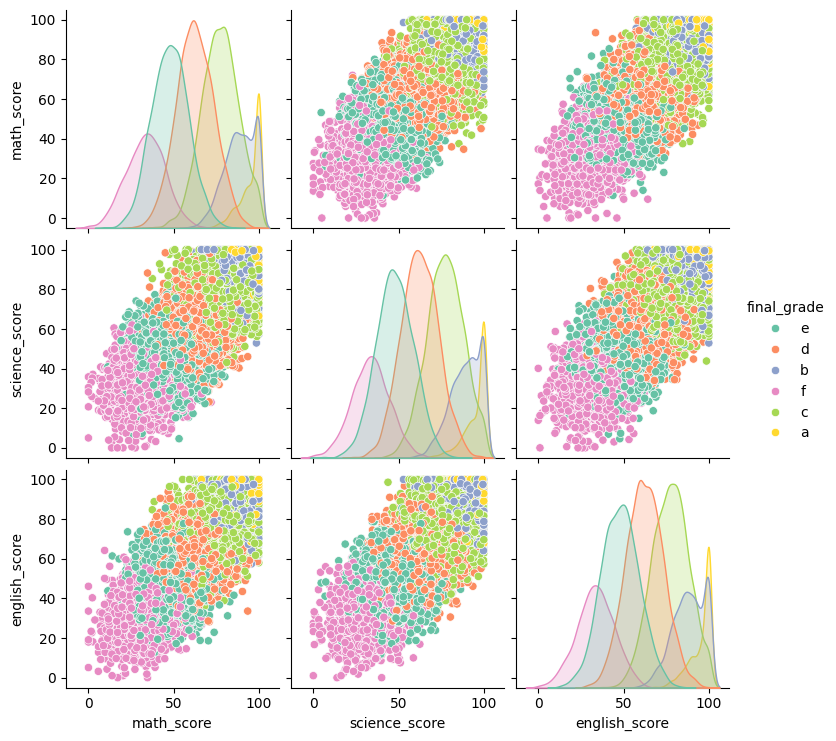

In [108]:


sns.pairplot(df, vars=['math_score','science_score','english_score'], hue='final_grade', palette='Set2')
plt.show()


C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\590447017.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='study_method',y='study_hours',data=df,palette='Set2',orient='v')


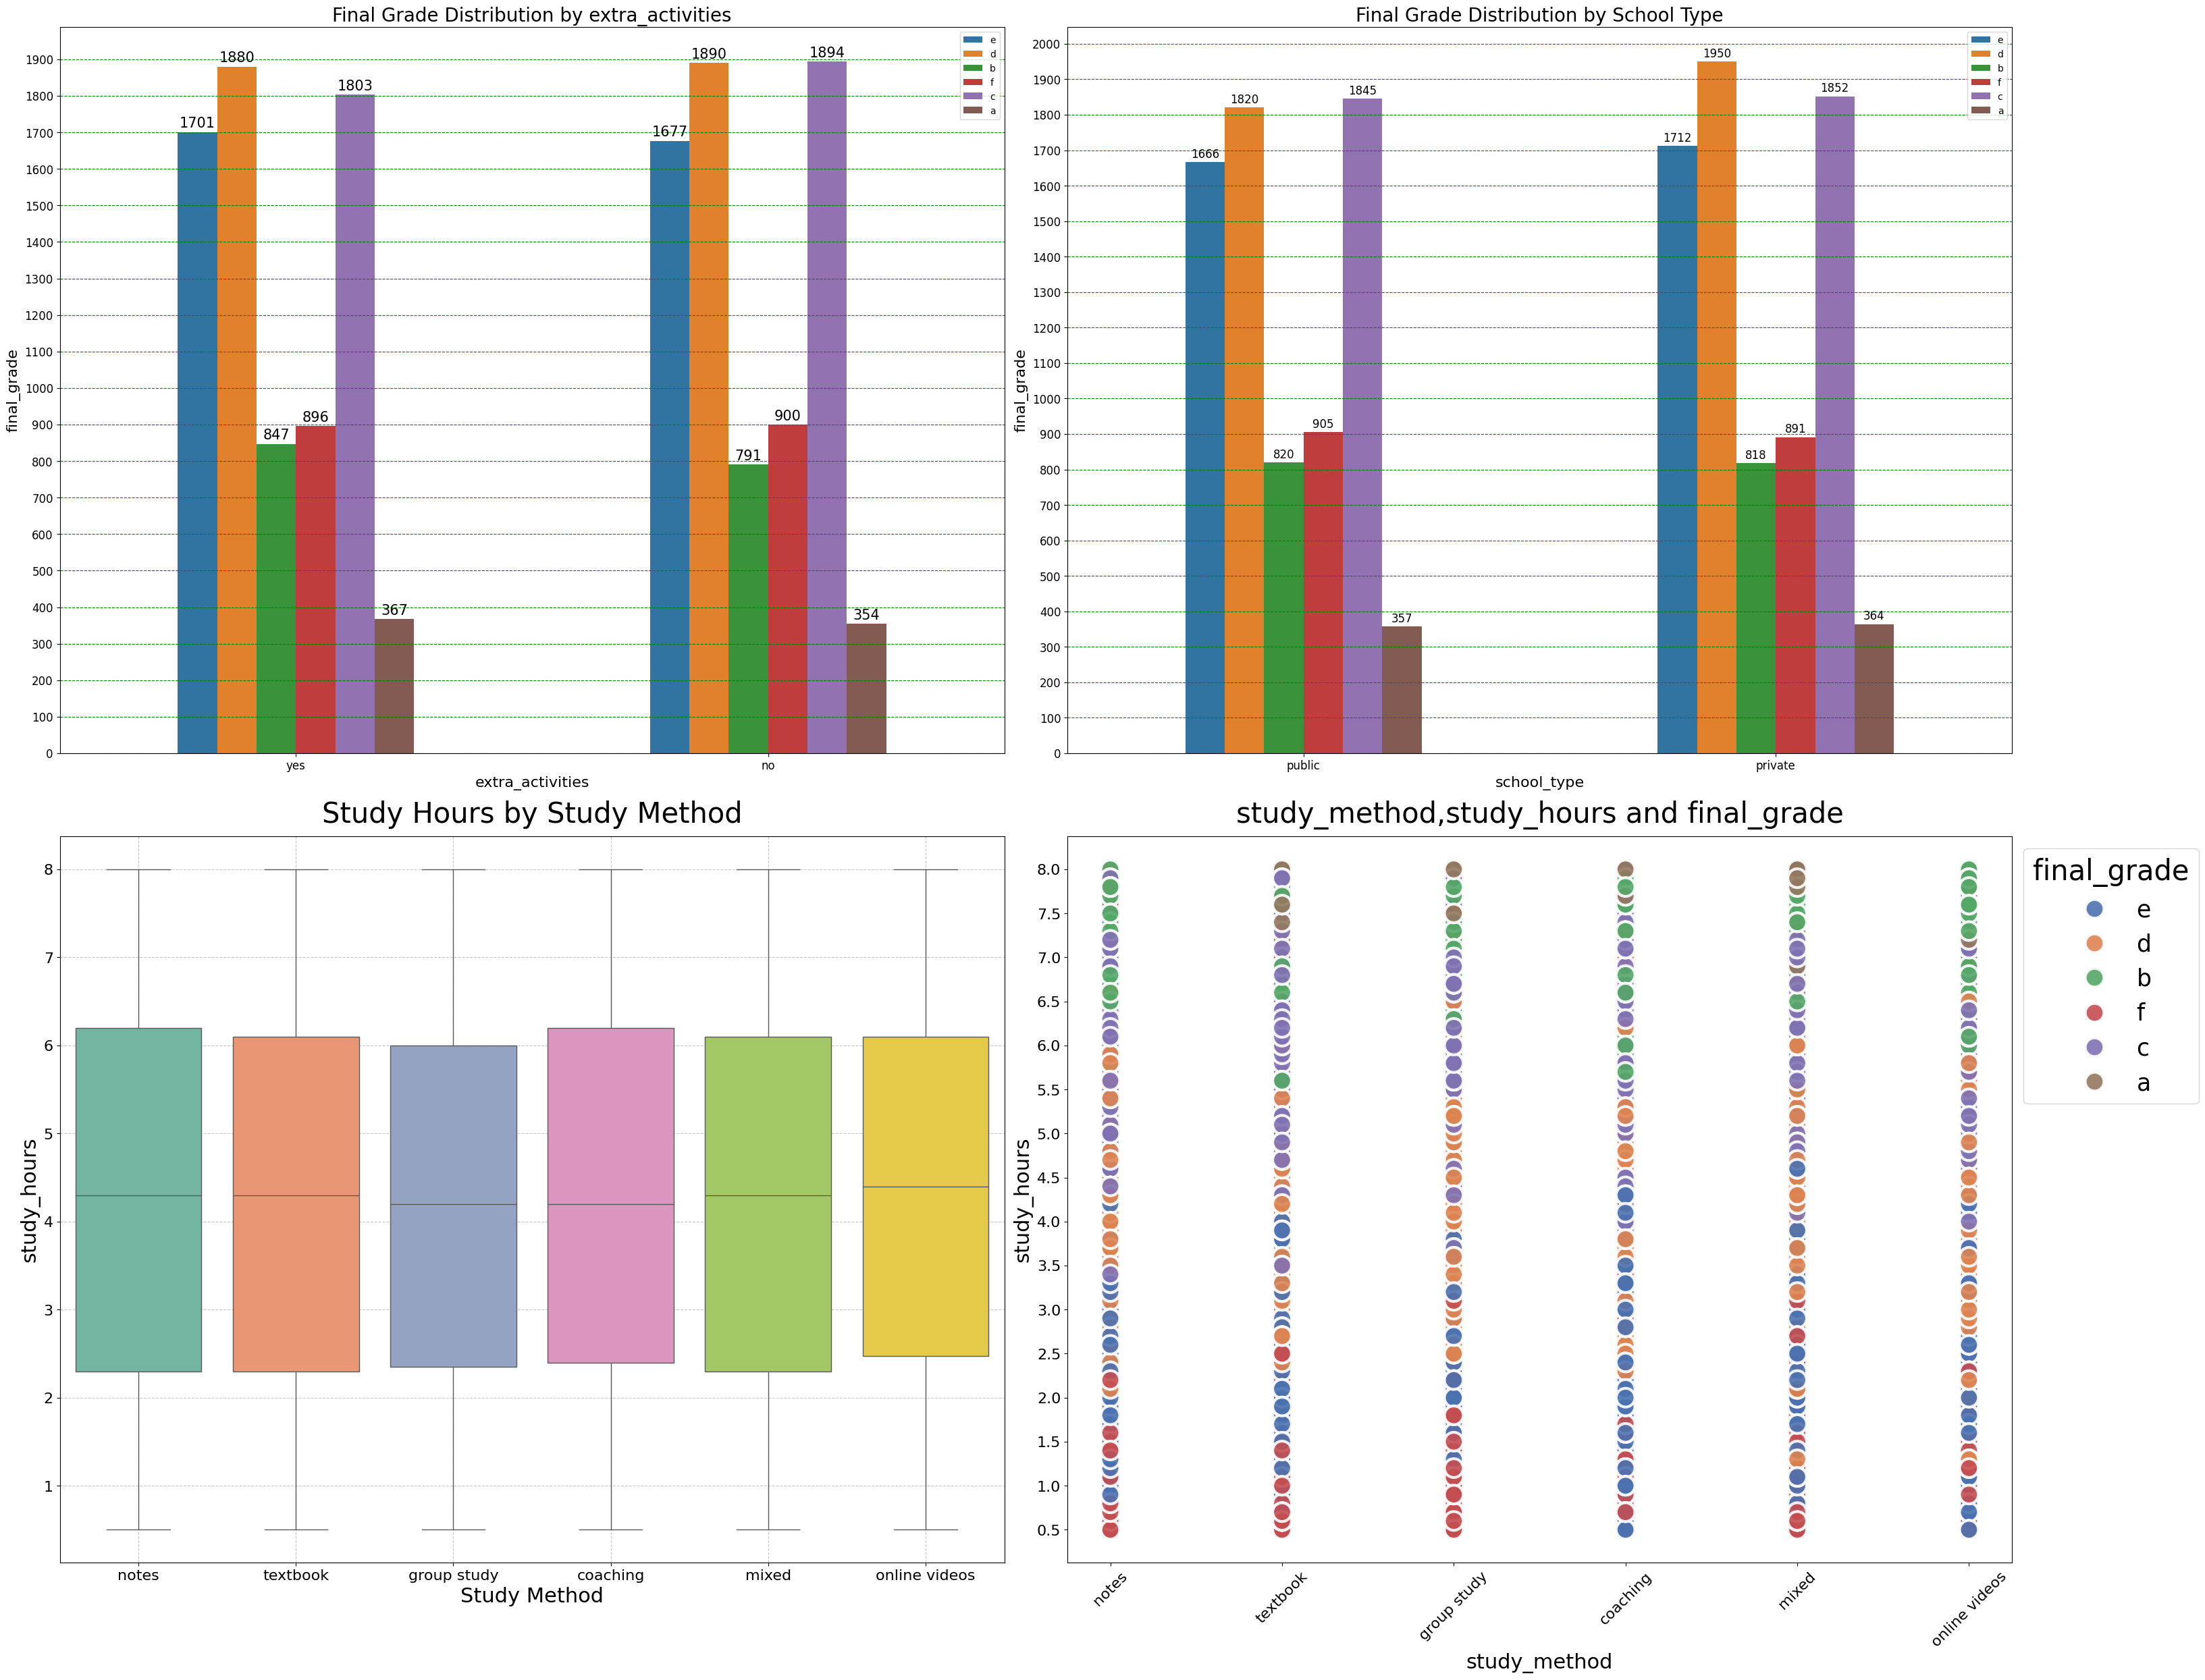

In [109]:
plt.figure(figsize=(30,24))
# subplot 1: Final Grade Distribution by extra_activities
plt.subplot(2,2,1)

ax=sns.countplot(x='extra_activities', hue='final_grade', data=df,width=0.5)
plt.title('Final Grade Distribution by extra_activities', fontsize=20) 
plt.xlabel('extra_activities', fontsize=16) 
plt.ylabel('final_grade', fontsize=16) 
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
plt.xticks(fontsize=12)
plt.yticks(range(0,2000,100),fontsize=12)

plt.legend() 
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=15, padding=2)


# subplot 2: Final Grade Distribution by School Type
plt.subplot(2,2,2)

ax=sns.countplot(x='school_type', hue='final_grade', data=df,width=0.5)
plt.title('Final Grade Distribution by School Type', fontsize=20) 
plt.xlabel('school_type', fontsize=16) 
plt.ylabel('final_grade', fontsize=16) 
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=2)
plt.yticks(range(0,2100,100),fontsize=12)
plt.xticks(fontsize=12)

plt.legend()



# subplot 3: Study Hours by Study Method
plt.subplot(2,2,3)

sns.boxplot(x='study_method',y='study_hours',data=df,palette='Set2',orient='v')

plt.title('Study Hours by Study Method', fontsize=30, pad=15)
plt.xlabel('Study Method', fontsize=22)
plt.ylabel('study_hours', fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# subplot 4: study_method,study_hours and final_grade
plt.subplot(2,2,4)

sns.scatterplot(x='study_method',y='study_hours',hue='final_grade',palette='deep',data=df,linewidth=3,alpha=0.9,s=400)
plt.title('study_method,study_hours and final_grade',fontsize=30,pad=15)
plt.xlabel('study_method',fontsize=22)
plt.ylabel('study_hours',fontsize=22)
plt.legend(title='final_grade',title_fontsize=30,fontsize=25,bbox_to_anchor=(1,1))

plt.xticks(rotation=45,fontsize=16)
plt.yticks(np.arange(0.5,8.5,0.5),fontsize=16)
plt.show()


#### **Drop Unneeded Columns**

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   school_type            15000 non-null  object 
 4   parent_education       15000 non-null  object 
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  object 
 8   travel_time            15000 non-null  object 
 9   extra_activities       15000 non-null  object 
 10  study_method           15000 non-null  object 
 11  math_score             15000 non-null  float64
 12  science_score          15000 non-null  float64
 13  english_score          15000 non-null  float64
 14  overall_score          15000 non-null  float64
 15  final_g

In [112]:
df.drop(columns=['student_id','school_type','internet_access','study_method','parent_education','travel_time','extra_activities'],inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\2615721323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['student_id','school_type','internet_access','study_method','parent_education','travel_time','extra_activities'],inplace=True)


In [113]:
df

,age,gender,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score,final_grade
0,14,male,3.1,84.3,42.7,55.4,57.0,53.1,e
1,18,female,3.7,87.8,57.6,68.8,64.8,61.3,d
2,17,female,7.9,65.5,84.8,95.0,79.2,89.6,b
3,16,other,1.1,58.1,44.4,27.5,54.7,41.6,e
4,16,female,1.3,61.0,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...
14995,17,male,1.8,53.2,37.1,37.1,26.8,38.4,f
14996,17,other,6.7,63.5,84.4,67.2,96.2,78.8,c
14997,17,male,5.2,58.2,69.0,57.2,74.1,64.3,d
14998,16,other,1.0,68.7,24.2,41.4,30.5,33.6,f


#### **x and y**

In [114]:
x=df.drop('final_grade',axis=1)
y=df[['final_grade']]

In [115]:
x

,age,gender,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
0,14,male,3.1,84.3,42.7,55.4,57.0,53.1
1,18,female,3.7,87.8,57.6,68.8,64.8,61.3
2,17,female,7.9,65.5,84.8,95.0,79.2,89.6
3,16,other,1.1,58.1,44.4,27.5,54.7,41.6
4,16,female,1.3,61.0,8.9,32.7,30.0,25.4
...,...,...,...,...,...,...,...,...
14995,17,male,1.8,53.2,37.1,37.1,26.8,38.4
14996,17,other,6.7,63.5,84.4,67.2,96.2,78.8
14997,17,male,5.2,58.2,69.0,57.2,74.1,64.3
14998,16,other,1.0,68.7,24.2,41.4,30.5,33.6


In [116]:
y

,final_grade
0,e
1,d
2,b
3,e
4,f
...,...
14995,f
14996,c
14997,d
14998,f


# label encoder

In [117]:
encoder=LabelEncoder()
x['gender']=encoder.fit_transform(x['gender'])


In [118]:
y['final_grade']=encoder.fit_transform(y['final_grade'])

C:\Users\Mega\AppData\Local\Temp\ipykernel_26080\3611736796.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['final_grade']=encoder.fit_transform(y['final_grade'])


In [119]:
x

,age,gender,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
0,14,1,3.1,84.3,42.7,55.4,57.0,53.1
1,18,0,3.7,87.8,57.6,68.8,64.8,61.3
2,17,0,7.9,65.5,84.8,95.0,79.2,89.6
3,16,2,1.1,58.1,44.4,27.5,54.7,41.6
4,16,0,1.3,61.0,8.9,32.7,30.0,25.4
...,...,...,...,...,...,...,...,...
14995,17,1,1.8,53.2,37.1,37.1,26.8,38.4
14996,17,2,6.7,63.5,84.4,67.2,96.2,78.8
14997,17,1,5.2,58.2,69.0,57.2,74.1,64.3
14998,16,2,1.0,68.7,24.2,41.4,30.5,33.6


In [120]:
y

,final_grade
0,4
1,3
2,1
3,4
4,5
...,...
14995,5
14996,2
14997,3
14998,5


# train_test_split

In [133]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=46,test_size=0.2)

# LogisticRegression

In [134]:
lr=LogisticRegression(max_iter=10000,C=10000,tol=0.0,random_state=10000)
lr.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0
,C,10000
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,10000
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [135]:
lr.score(x_train,y_train)

0.9925833333333334

In [136]:
lr.score(x_test,y_test)

0.9936666666666667

In [137]:
y_pred=lr.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 581    2    0    0    0    0]
 [   3 1280   10    0    0    0]
 [   0   12 2942   10    0    0]
 [   0    0   18 2973   17    0]
 [   0    0    0    9 2678    6]
 [   0    0    0    0    2 1457]]


In [138]:
y_pred=lr.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[137   0   0   0   0   0]
 [  0 342   2   0   0   0]
 [  0   2 720   0   0   0]
 [  0   0   5 773   2   0]
 [  0   0   0   5 676   0]
 [  0   0   0   0   3 333]]


# svc

In [139]:
svm=SVC(C=10,gamma='scale',tol=0.05)
svm.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.05
,cache_size,200
,class_weight,None
,verbose,False


In [140]:
svm.score(x_train,y_train)

0.987

In [141]:
svm.score(x_test,y_test)

0.9833333333333333

In [143]:
y_pred_train = svm.predict(x_train)
print(confusion_matrix(y_train, y_pred_train))


[[ 560   24    0    0    0    0]
 [   9 1257   28    0    0    0]
 [   0    6 2937   27    0    0]
 [   0    0   12 2957   23    0]
 [   0    0    0    8 2679   10]
 [   0    0    0    0    9 1454]]


In [144]:
y_pred=svm.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[131   0   0   0   0   0]
 [  6 338   3   0   0   0]
 [  0   6 714   2   0   0]
 [  0   0  10 766   5   0]
 [  0   0   0  10 670   2]
 [  0   0   0   0   6 331]]


# DecisionTreeClassifier


In [145]:
tree=DecisionTreeClassifier(criterion='gini',splitter='best',ccp_alpha=0,min_samples_split=2,min_samples_leaf =1,random_state=5)
tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [146]:
tree.score(x_train,y_train)

1.0

In [147]:
tree.score(x_test,y_test)

0.9973333333333333

In [148]:
y_pred=tree.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 584    0    0    0    0    0]
 [   0 1294    0    0    0    0]
 [   0    0 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [149]:
y_pred=tree.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[137   0   0   0   0   0]
 [  0 344   1   0   0   0]
 [  0   0 724   2   0   0]
 [  0   0   2 775   0   0]
 [  0   0   0   1 679   0]
 [  0   0   0   0   2 333]]


# KNeighborsClassifier

In [157]:
neighbors=KNeighborsClassifier(n_neighbors=1,leaf_size=70,weights='uniform',algorithm='auto',n_jobs=2,p=1)
neighbors.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,70
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,2


In [158]:
neighbors.score(x_train,y_train)

1.0

In [159]:
neighbors.score(x_test,y_test)

0.887

In [161]:
y_pred=neighbors.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 584    0    0    0    0    0]
 [   0 1294    0    0    0    0]
 [   0    0 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [160]:
y_pred=neighbors.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[121  14   0   0   0   0]
 [ 16 297  28   0   0   0]
 [  0  33 652  39   0   0]
 [  0   0  47 681  41   0]
 [  0   0   0  58 605  28]
 [  0   0   0   0  35 305]]


RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier

In [162]:
rf=RandomForestClassifier(n_estimators=100,criterion='gini',random_state=2)
rf.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [163]:
rf.score(x_train,y_train)

1.0

In [164]:
rf.score(x_test,y_test)

0.9976666666666667

In [165]:
y_pred=rf.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 584    0    0    0    0    0]
 [   0 1294    0    0    0    0]
 [   0    0 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [166]:
y_pred=rf.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[137   0   0   0   0   0]
 [  0 343   1   0   0   0]
 [  0   1 725   1   0   0]
 [  0   0   1 776   0   0]
 [  0   0   0   1 679   0]
 [  0   0   0   0   2 333]]


In [167]:
ext=ExtraTreesClassifier(n_estimators=480,criterion='gini',min_samples_split=8)
ext.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,480
,criterion,'gini'
,max_depth,None
,min_samples_split,8
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [168]:
ext.score(x_train,y_train)

0.9998333333333334

In [169]:
ext.score(x_test,y_test)

0.9726666666666667

In [170]:
y_pred=ext.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 583    0    0    0    0    0]
 [   1 1293    0    0    0    0]
 [   0    1 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [171]:
y_pred=ext.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[129   0   0   0   0   0]
 [  8 331   2   0   0   0]
 [  0  13 710   8   0   0]
 [  0   0  15 762  12   0]
 [  0   0   0   8 662   9]
 [  0   0   0   0   7 324]]


In [172]:
bag=BaggingClassifier(n_estimators=250)
bag.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,250
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [173]:
bag.score(x_train,y_train)

1.0

In [174]:
bag.score(x_test,y_test)

0.997

In [175]:
y_pred=bag.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 584    0    0    0    0    0]
 [   0 1294    0    0    0    0]
 [   0    0 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [176]:
y_pred=bag.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[137   0   0   0   0   0]
 [  0 343   1   0   0   0]
 [  0   1 724   2   0   0]
 [  0   0   2 776   0   0]
 [  0   0   0   0 679   1]
 [  0   0   0   0   2 332]]


In [177]:
ada=AdaBoostClassifier(n_estimators=1000,learning_rate=0.01,random_state=20)
ada.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,1000
,learning_rate,0.01
,algorithm,'deprecated'
,random_state,20


In [178]:
ada.score(x_train,y_train)

0.7200833333333333

In [179]:
ada.score(x_test,y_test)

0.727

In [180]:
y_pred=ada.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[   0    0    0    0    0    0]
 [   0    0    0    0    0    0]
 [ 584 1294 2958    0    0    0]
 [   0    0   12 2992    6    0]
 [   0    0    0    0 2691 1463]
 [   0    0    0    0    0    0]]


In [181]:
y_pred=ada.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [137 344 725   0   0   0]
 [  0   0   2 778   3   0]
 [  0   0   0   0 678 333]
 [  0   0   0   0   0   0]]


In [182]:
vot=VotingClassifier(estimators=[('t1',KNeighborsClassifier(n_neighbors=7,leaf_size=30,weights='uniform',algorithm='auto')),
                                 ('t2',DecisionTreeClassifier(criterion='gini',splitter='best')),
                                 ('t3',LogisticRegression(max_iter=1000,C=10)),
                                 ('t4',SVC(gamma='scale',C=12,max_iter=100))])
vot.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://

,estimators,"[('t1', ...), ('t2', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2


In [183]:
vot.score(x_train,y_train)

0.9746666666666667

In [184]:
vot.score(x_test,y_test)

0.9606666666666667

In [185]:
y_pred=vot.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 569    6    0    0    0    0]
 [  15 1269   46    0    0    0]
 [   0   19 2894   57    0    0]
 [   0    0   30 2904   49    0]
 [   0    0    0   31 2639   42]
 [   0    0    0    0    9 1421]]


In [186]:
y_pred=vot.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[131   0   0   0   0   0]
 [  6 338   9   0   0   0]
 [  0   6 704  22   0   0]
 [  0   0  14 741  18   0]
 [  0   0   0  15 652  17]
 [  0   0   0   0  11 316]]


# xgboost

In [187]:
xgb=XGBClassifier()
xgb.fit(x_train,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [188]:
xgb.score(x_train,y_train)

1.0

In [189]:
xgb.score(x_test,y_test)

0.9956666666666667

In [190]:
y_pred=xgb.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 584    0    0    0    0    0]
 [   0 1294    0    0    0    0]
 [   0    0 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [191]:
y_pred=xgb.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[135   0   0   0   0   0]
 [  2 343   1   0   0   0]
 [  0   1 724   1   0   0]
 [  0   0   2 776   0   0]
 [  0   0   0   1 677   1]
 [  0   0   0   0   4 332]]


# catboost

In [192]:
cat=CatBoostClassifier()
cat.fit(x_train,y_train)

Learning rate set to 0.089818
0:	learn: 1.3836262	total: 211ms	remaining: 3m 31s
1:	learn: 1.1494925	total: 258ms	remaining: 2m 8s
2:	learn: 0.9721605	total: 283ms	remaining: 1m 34s
3:	learn: 0.8437166	total: 300ms	remaining: 1m 14s
4:	learn: 0.7359360	total: 316ms	remaining: 1m 2s
5:	learn: 0.6488658	total: 333ms	remaining: 55.2s
6:	learn: 0.5752873	total: 351ms	remaining: 49.8s
7:	learn: 0.5132485	total: 367ms	remaining: 45.5s
8:	learn: 0.4606395	total: 383ms	remaining: 42.2s
9:	learn: 0.4133291	total: 397ms	remaining: 39.3s
10:	learn: 0.3720751	total: 410ms	remaining: 36.8s
11:	learn: 0.3358259	total: 423ms	remaining: 34.8s
12:	learn: 0.3037880	total: 439ms	remaining: 33.3s
13:	learn: 0.2754293	total: 460ms	remaining: 32.4s
14:	learn: 0.2499746	total: 472ms	remaining: 31s
15:	learn: 0.2271281	total: 488ms	remaining: 30s
16:	learn: 0.2072039	total: 505ms	remaining: 29.2s
17:	learn: 0.1895790	total: 520ms	remaining: 28.4s
18:	learn: 0.1733687	total: 534ms	remaining: 27.6s
19:	learn: 0

In [193]:
cat.score(x_train,y_train)

np.float64(1.0)

In [194]:
cat.score(x_test,y_test)

np.float64(0.9963333333333333)

In [195]:
y_pred=cat.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 584    0    0    0    0    0]
 [   0 1294    0    0    0    0]
 [   0    0 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [196]:
y_pred=cat.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[136   2   0   0   0   0]
 [  1 341   1   0   0   0]
 [  0   1 724   1   0   0]
 [  0   0   2 776   0   0]
 [  0   0   0   1 680   1]
 [  0   0   0   0   1 332]]


# lightgmb

In [197]:
light=LGBMClassifier()
light.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1356
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 8
[LightGBM] [Info] Start training from score -3.022761
[LightGBM] [Info] Start training from score -2.227168
[LightGBM] [Info] Start training from score -1.396345
[LightGBM] [Info] Start training from score -1.388965
[LightGBM] [Info] Start training from score -1.492767
[LightGBM] [Info] Start training from score -2.104418
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [198]:
light.score(x_train,y_train)

1.0

In [199]:
light.score(x_test,y_test)

0.9956666666666667

In [200]:
y_pred=light.predict(x_train)
print(confusion_matrix(y_pred,y_train))

[[ 584    0    0    0    0    0]
 [   0 1294    0    0    0    0]
 [   0    0 2970    0    0    0]
 [   0    0    0 2992    0    0]
 [   0    0    0    0 2697    0]
 [   0    0    0    0    0 1463]]


In [201]:
y_pred=light.predict(x_test)
print(confusion_matrix(y_pred,y_test))

[[136   1   0   0   0   0]
 [  1 342   2   0   0   0]
 [  0   1 724   3   0   0]
 [  0   0   1 774   0   0]
 [  0   0   0   1 679   1]
 [  0   0   0   0   2 332]]


# DEEP LEARNING

In [203]:
x_train.shape

(12000, 8)

In [204]:


model = Sequential([
    Dense(64, activation='relu', input_dim=8),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')   # عدد الفئات = 6
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [205]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,286 (12.84 KB)

 Trainable params: 3,286 (12.84 KB)

 Non-trainable params: 0 (0.00 B)

In [206]:
earlystop=EarlyStopping(monitor='val_loss',patience=20,restore_best_weights=True)
reducelr=ReduceLROnPlateau(monitor='val_loss',patience=14,factor=0.1)
logger=CSVLogger('file.csv')
weight=ModelCheckpoint('weight.h5')

In [207]:
model.fit(x_train, y_train, epochs=100,validation_split=0.3,callbacks=[earlystop,reducelr,logger,weight])

Epoch 1/100
255/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3224 - loss: 4.1041

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3945 - loss: 2.0209 - val_accuracy: 0.4786 - val_loss: 1.1892 - learning_rate: 0.0010
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4853 - loss: 1.1344

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5081 - loss: 1.0794 - val_accuracy: 0.5819 - val_loss: 0.9307 - learning_rate: 0.0010
Epoch 3/100
253/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5818 - loss: 0.9175

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6108 - loss: 0.8609 - val_accuracy: 0.6497 - val_loss: 0.7667 - learning_rate: 0.0010
Epoch 4/100
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6599 - loss: 0.7567

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6690 - loss: 0.7360 - val_accuracy: 0.6603 - val_loss: 0.7580 - learning_rate: 0.0010
Epoch 5/100
250/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6804 - loss: 0.7058

...

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9250 - loss: 0.1749 - val_accuracy: 0.9433 - val_loss: 0.1324 - learning_rate: 0.0010
Epoch 97/100
252/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9405 - loss: 0.1415

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9417 - loss: 0.1395 - val_accuracy: 0.9269 - val_loss: 0.1524 - learning_rate: 0.0010
Epoch 98/100
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9249 - loss: 0.1693

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9202 - loss: 0.1816 - val_accuracy: 0.9508 - val_loss: 0.1288 - learning_rate: 0.0010
Epoch 99/100
247/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9349 - loss: 0.1528

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9271 - loss: 0.1687 - val_accuracy: 0.9503 - val_loss: 0.1273 - learning_rate: 0.0010
Epoch 100/100
239/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9437 - loss: 0.1341

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9440 - loss: 0.1323 - val_accuracy: 0.8897 - val_loss: 0.2204 - learning_rate: 0.0010


In [208]:
model.evaluate(x_train,y_train)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9670 - loss: 0.1066


[0.10660605132579803, 0.9670000076293945]

In [209]:
model.evaluate(x_test,y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9593 - loss: 0.1178


[0.1178046464920044, 0.9593333601951599]